# 🔍 Credit Risk Model — Investigation Notebook

This notebook provides a **comprehensive investigation** of the full ML pipeline.

**Structure:**
1. **Data Inspection** — Load train data, split into train/validation, inspect train set only
2. **Training Helpers** — Utility functions for running experiments
3. **LRC Experiments** — Logistic Regression (4 configs: baseline/FE × tune/no-tune)
4. **RFC Experiments** — Random Forest (4 configs)
5. **SVC Experiments** — Support Vector Classifier (4 configs)
6. **CatBoost Experiments** — CatBoost (4 configs)
7. **Results Comparison** — Side-by-side metrics, visual comparison, key findings
   - *Option to load pre-trained models from MLflow registry and skip Sections 3–6*
8. **Ensemble Scoring** — Weighted soft-voting ensemble on validation data
   - Weight sweep → optimal weights → scoring with default & tuned threshold → comparison
9. **Final Test-Set Evaluation** — Score all models + ensemble on the hold-out test set
   - Individual model scores → ensemble score → comparison charts → final verdict

**Models:** Logistic Regression (LRC), Random Forest (RFC), SVC, CatBoost
**Configs per model:** baseline no-tune, baseline tuned, feature-engineered no-tune, feature-engineered tuned

In [5]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import category_encoders as ce

# Make sure the src package is importable from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_risk_model.config.core import config, DATA_DIR, SingleModelConfig
from credit_risk_model.processing.features import FeatureEngineer, BaselineEngineer
from credit_risk_model.processing.preprocessors import (
    build_pipeline,
    build_column_transformer,
    build_catboost_pipeline,
    build_catboost_input,
)
from credit_risk_model.processing.catboost_wrapper import CatBoostSklearnWrapper
from credit_risk_model.tracking.metrics import evaluate_model, calculate_cost
from credit_risk_model.tracking.visualizations import (
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_learning_curve,
)
from credit_risk_model.training.train_lrc import LRCTrainer
from credit_risk_model.training.train_rf import RFTrainer
from credit_risk_model.training.train_svc import SVCTrainer
from credit_risk_model.training.train_catboost import CatBoostTrainer

# Plotting defaults
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("✅ All imports successful")
print(f"📂 DATA_DIR: {DATA_DIR}")
print(f"📋 Config target: '{config.target}', val_size: {config.val_size}, random_state: {config.random_state}")
print(f"💰 Cost matrix: FP={config.cost_matrix.false_positive}, FN={config.cost_matrix.false_negative}")

✅ All imports successful
📂 DATA_DIR: /Users/fotisn/code/repos/credit_risk/credit-risk-project/data/processed
📋 Config target: 'class', val_size: 150, random_state: 8
💰 Cost matrix: FP=5.0, FN=1.0


---
## 1. Data Loading & Train/Validation Split

We load the processed training data and split it into train and validation sets using the **same** parameters as the production pipeline (`val_size=150`, `stratify`, `random_state=8`).

> ⚠️ All data inspection below is performed on the **training set only** to avoid data leakage.

In [6]:
# Load the processed training data
train_df = pd.read_csv(DATA_DIR / config.training_data_file)
print(f"📊 Full training data shape: {train_df.shape}")

# Separate features and target
X_full = train_df.drop(columns=[config.target])
y_full = train_df[config.target]

# Train/validation split — mirrors main.py exactly
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=config.val_size,
    stratify=y_full,
    random_state=config.random_state,
)

print(f"\n🔀 Split results:")
print(f"   X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")
print(f"\n📈 Target distribution (train):")
print(y_train.value_counts().to_frame("count").assign(pct=lambda d: (d["count"] / len(y_train) * 100).round(1)))
print(f"\n📈 Target distribution (val):")
print(y_val.value_counts().to_frame("count").assign(pct=lambda d: (d["count"] / len(y_val) * 100).round(1)))

📊 Full training data shape: (841, 21)

🔀 Split results:
   X_train: (691, 20)  |  y_train: (691,)
   X_val:   (150, 20)  |  y_val:   (150,)

📈 Target distribution (train):
       count   pct
class             
1        488  70.6
0        203  29.4

📈 Target distribution (val):
       count   pct
class             
1        106  70.7
0         44  29.3


### 1.1 Data Types & Missing Values

In [7]:
print("=" * 60)
print("DATA TYPES & MISSING VALUES (Train Set)")
print("=" * 60)

# Summary info
dtype_summary = X_train.dtypes.value_counts().to_frame("count")
print(f"\nColumn type counts:\n{dtype_summary}\n")

# Detailed column info
info_df = pd.DataFrame({
    "dtype": X_train.dtypes,
    "non_null": X_train.notnull().sum(),
    "null_count": X_train.isnull().sum(),
    "null_pct": (X_train.isnull().sum() / len(X_train) * 100).round(2),
    "n_unique": X_train.nunique(),
    "sample_value": X_train.iloc[0],
})
print(info_df.to_string())

# Identify numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print(f"\n📊 Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"📊 Categorical columns ({len(categorical_cols)}): {categorical_cols}")

DATA TYPES & MISSING VALUES (Train Set)

Column type counts:
        count
object     13
int64       7

                                      dtype  non_null  null_count  null_pct  n_unique                sample_value
checking_account_status              object       691           0       0.0         4           0 <= ... < 200 DM
duration_months                       int64       691           0       0.0        30                          12
credit_history                       object       691           0       0.0         5  existing credits paid duly
purpose                              object       691           0       0.0        10         furniture/equipment
credit_amount                         int64       691           0       0.0       650                         983
savings_account_bonds                object       691           0       0.0         5                  >= 1000 DM
present_employment_since             object       691           0       0.0         5             

### 1.2 Descriptive Statistics — Numeric Features

In [8]:
X_train[numeric_cols].describe().round(2)

,duration_months,credit_amount,installment_rate_pct_of_disp_income,present_residence_since,age_years,existing_credits_count,people_liable_for_maintenance
count,691.00,691.00,691.00,691.00,691.00,691.00,691.00
mean,20.52,3249.04,2.97,2.85,35.52,1.41,1.15
std,11.87,2786.29,1.12,1.11,11.23,0.59,0.35
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1349.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.00,3.00,3.00,33.00,1.00,1.00
75%,24.00,3998.00,4.00,4.00,42.00,2.00,1.00
max,72.00,15857.00,4.00,4.00,75.00,4.00,2.00


### 1.3 Numeric Feature Distributions

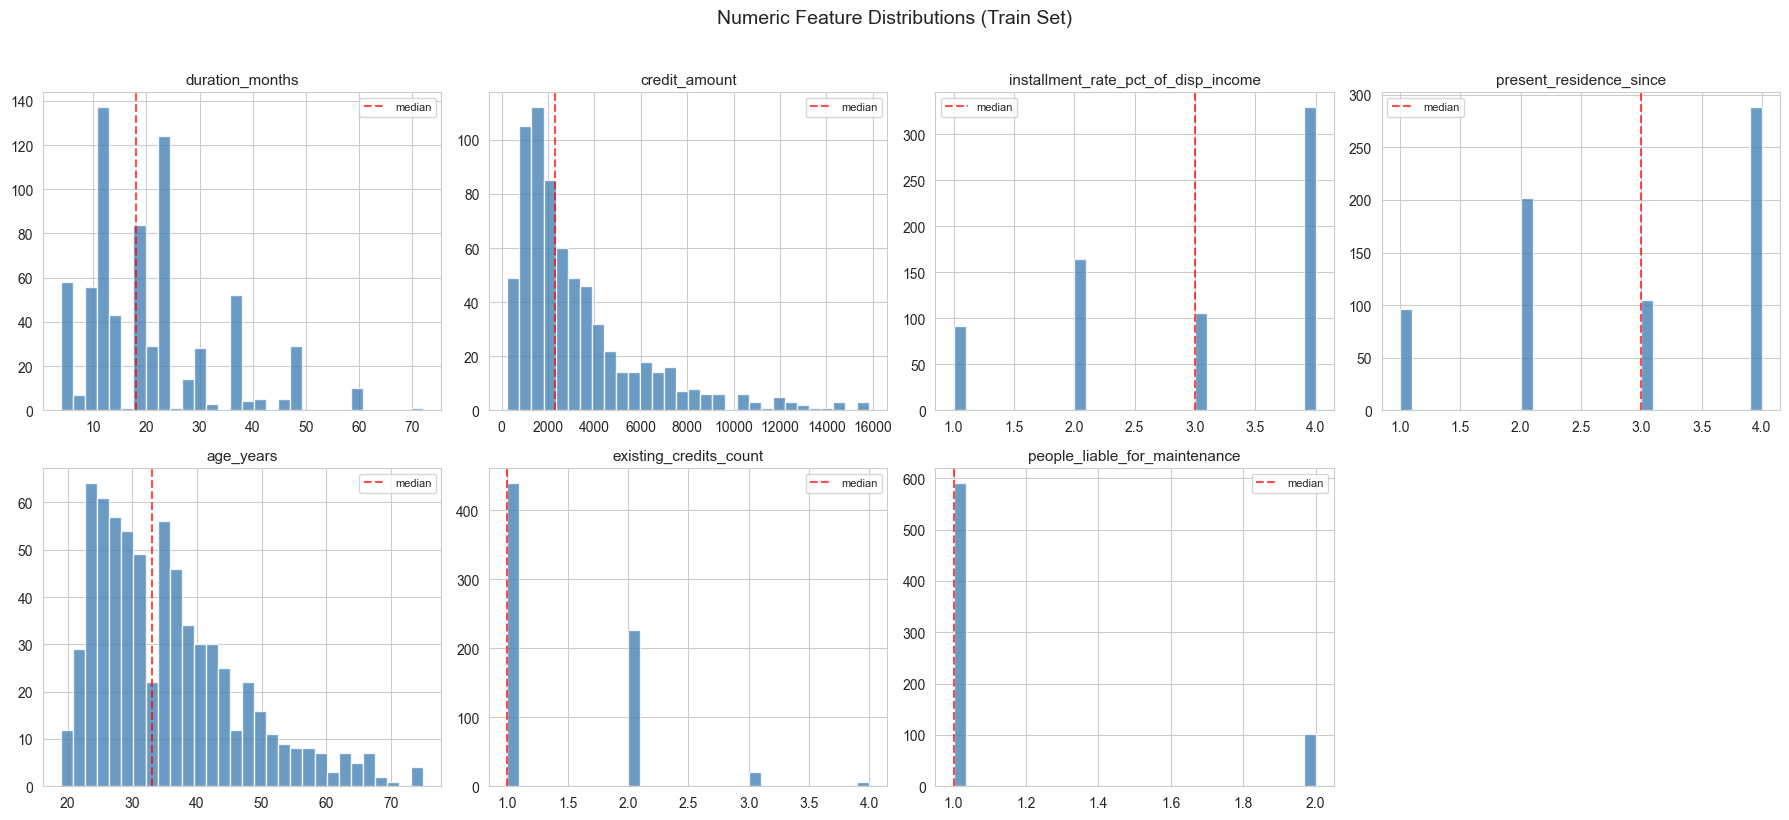

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, col in enumerate(numeric_cols):
    ax = axes.flat[idx] if idx < len(axes.flat) else None
    if ax is None:
        break
    X_train[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.axvline(X_train[col].median(), color="red", linestyle="--", alpha=0.7, label="median")
    ax.legend(fontsize=8)

# Hide unused axes
for idx in range(len(numeric_cols), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.suptitle("Numeric Feature Distributions (Train Set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Categorical Feature Value Counts

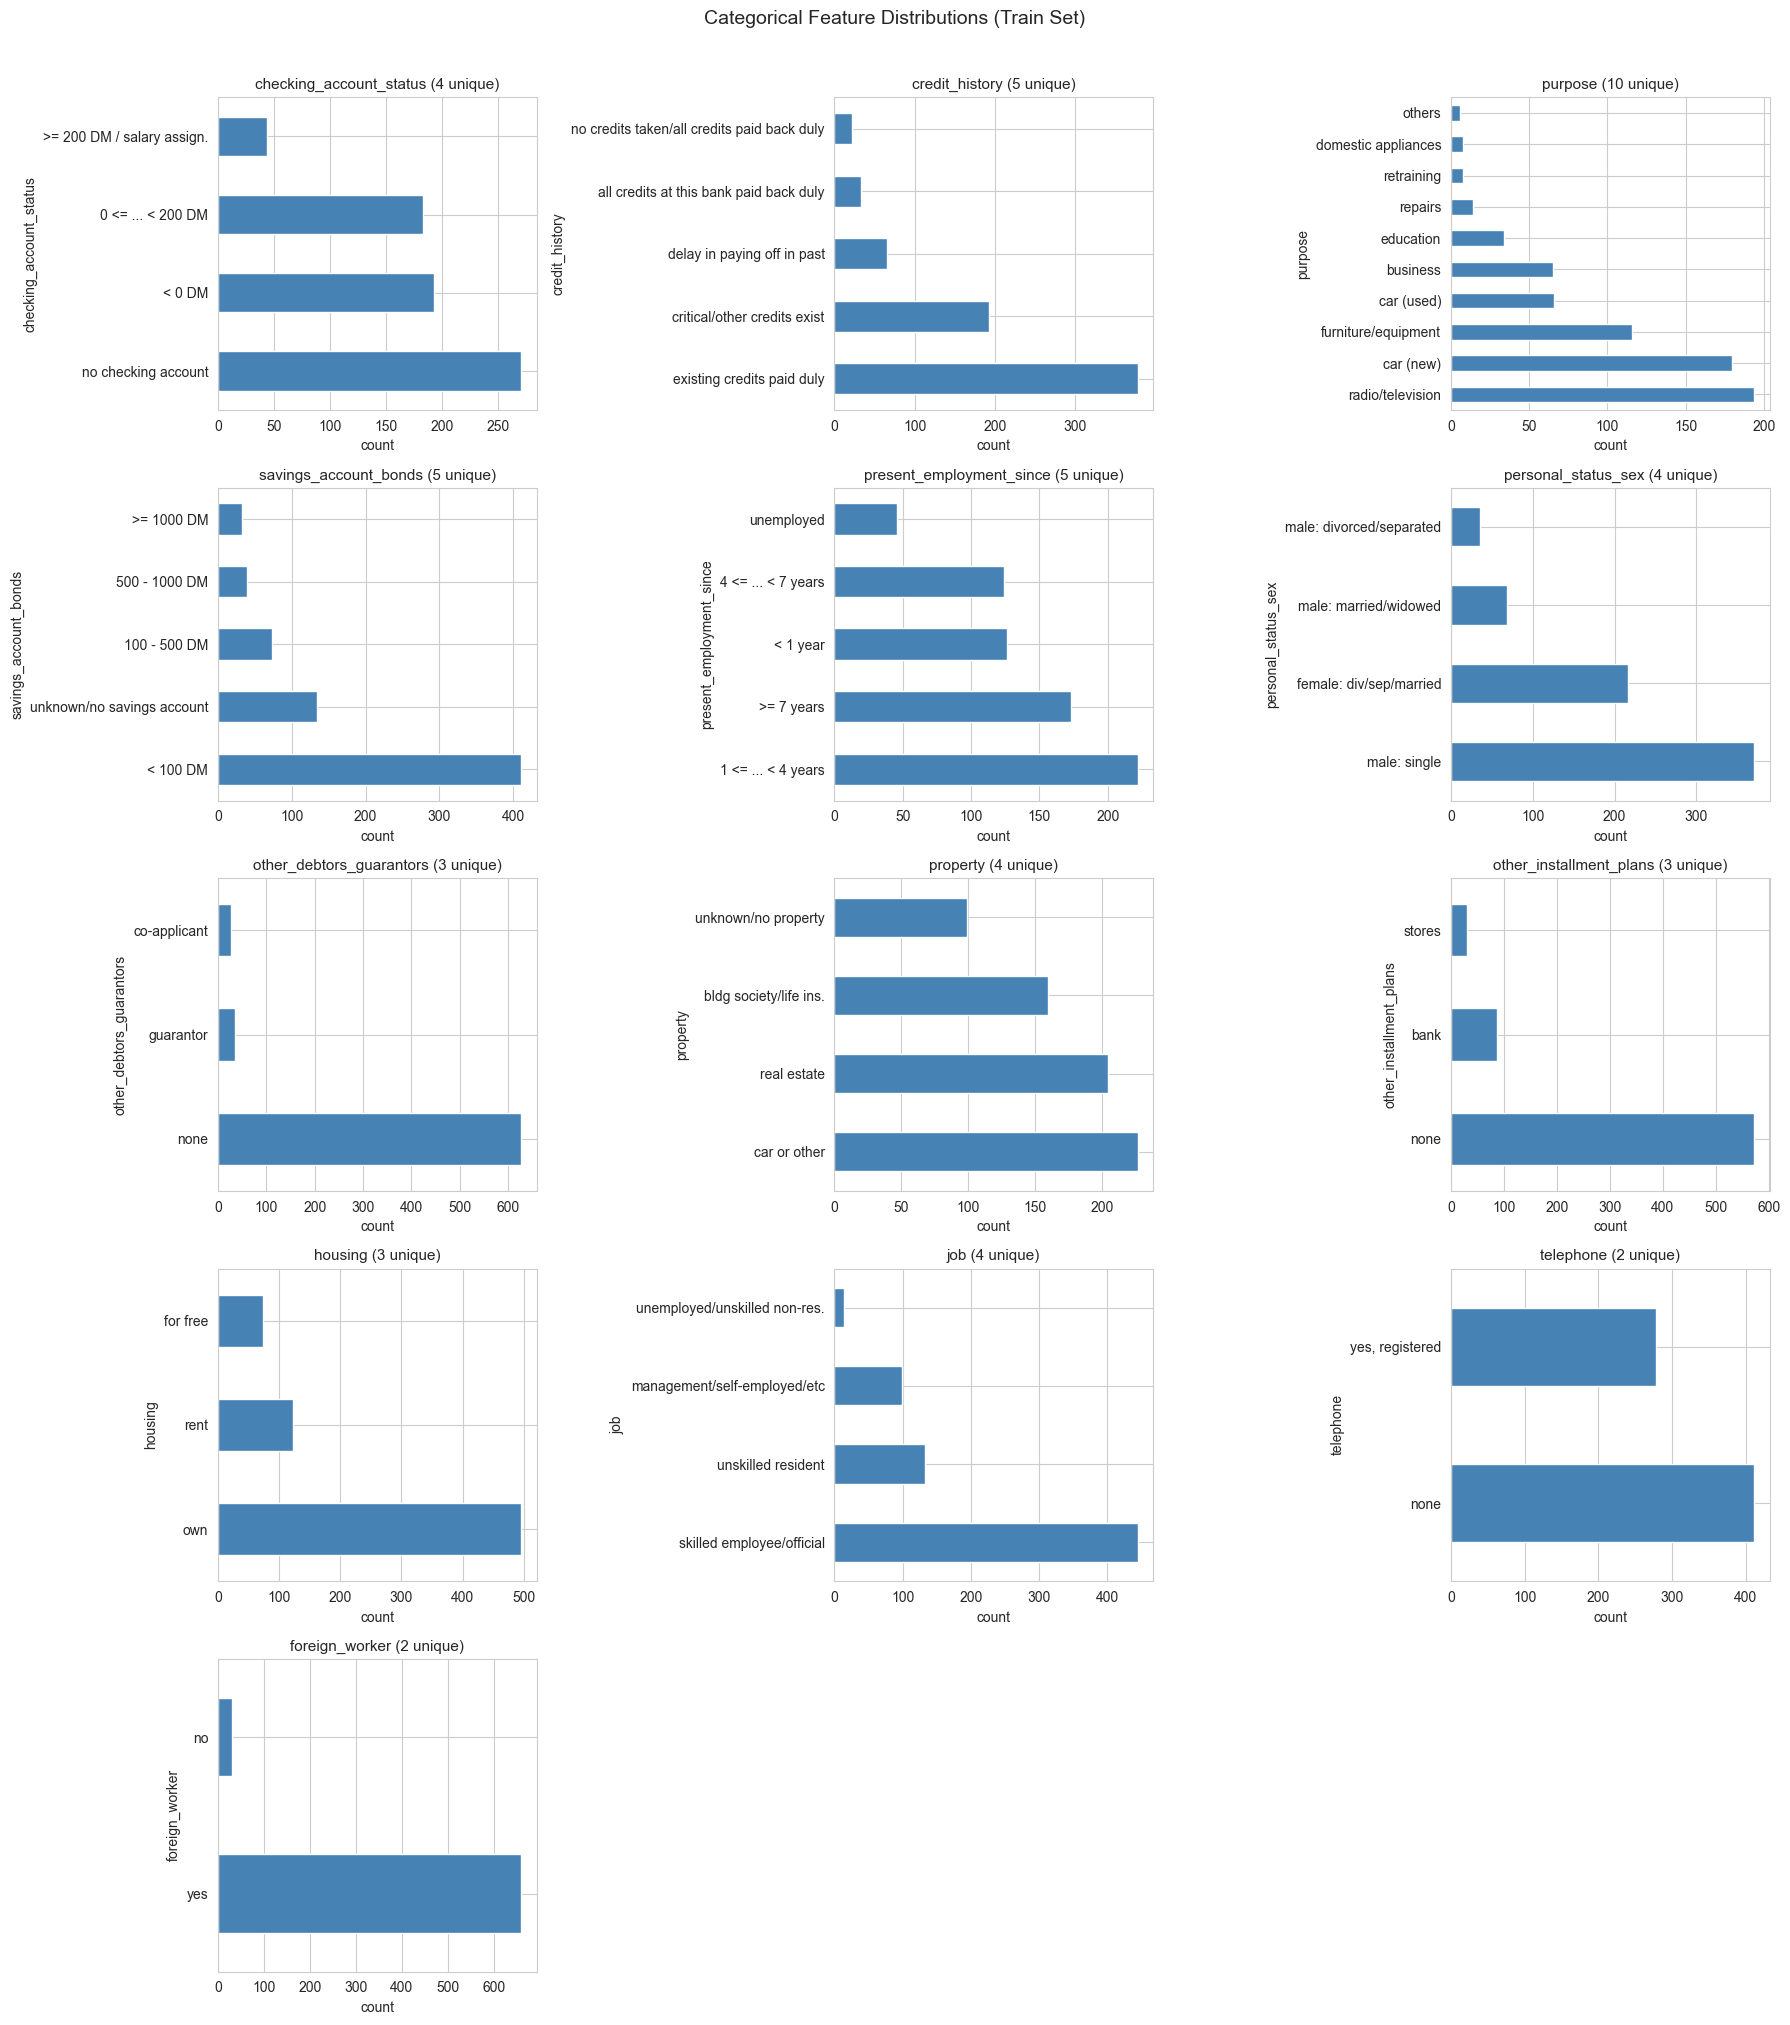

In [10]:
n_cats = len(categorical_cols)
fig, axes = plt.subplots((n_cats + 2) // 3, 3, figsize=(18, 4 * ((n_cats + 2) // 3)))
axes = axes.flat

for idx, col in enumerate(categorical_cols):
    counts = X_train[col].value_counts()
    counts.plot.barh(ax=axes[idx], color="steelblue", edgecolor="white")
    axes[idx].set_title(f"{col} ({counts.shape[0]} unique)", fontsize=11)
    axes[idx].set_xlabel("count")

for idx in range(n_cats, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Categorical Feature Distributions (Train Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix (Numeric Features)

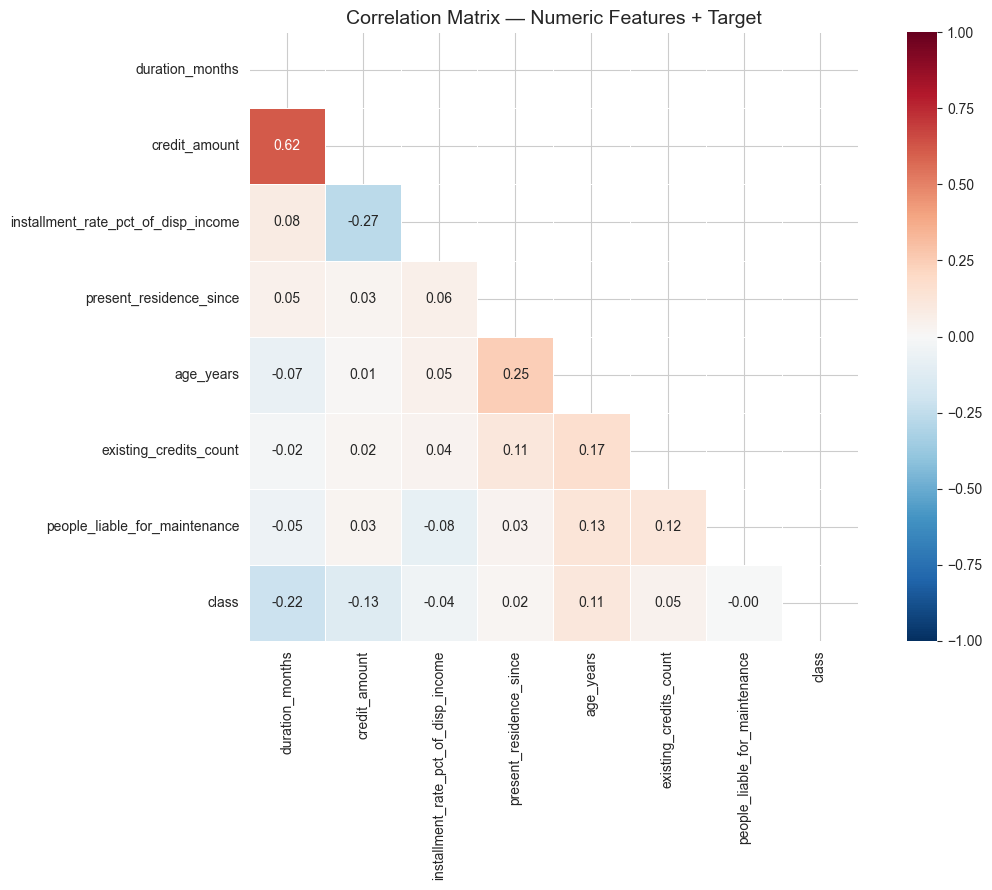

📊 Strongest correlations with target (class):
                                     correlation
duration_months                           -0.218
credit_amount                             -0.128
age_years                                  0.114
existing_credits_count                     0.045
installment_rate_pct_of_disp_income       -0.044
present_residence_since                    0.022
people_liable_for_maintenance             -0.003


In [11]:
# Include target in correlation analysis
corr_df = X_train[numeric_cols].copy()
corr_df[config.target] = y_train.values
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Matrix — Numeric Features + Target", fontsize=14)
plt.tight_layout()
plt.show()

# Show strongest correlations with target
target_corr = corr_matrix[config.target].drop(config.target).sort_values(key=abs, ascending=False)
print("📊 Strongest correlations with target (class):")
print(target_corr.to_frame("correlation").round(3))

### 1.6 Target vs Key Features

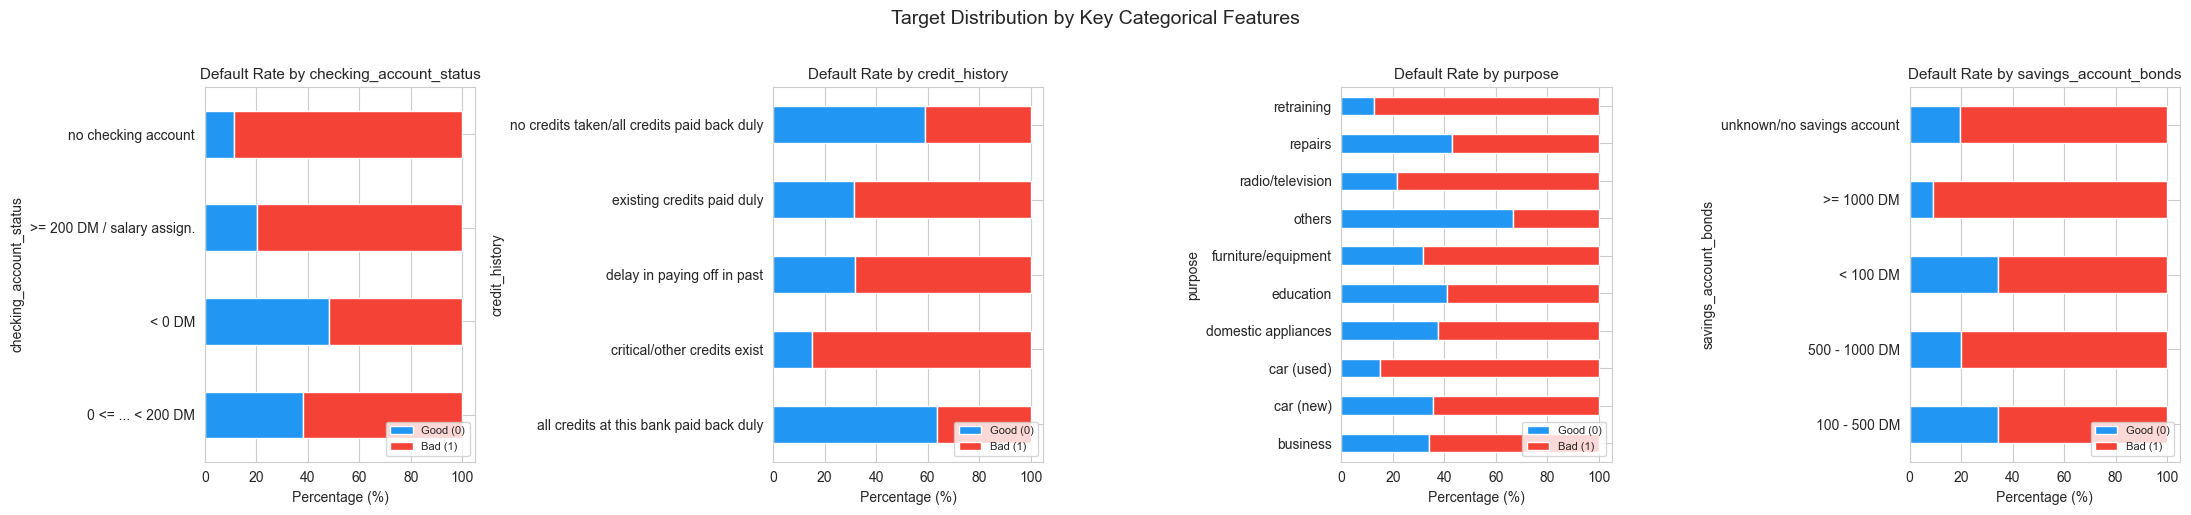

In [12]:
# Target rate by key categorical features
key_cats = ["checking_account_status", "credit_history", "purpose", "savings_account_bonds"]
fig, axes = plt.subplots(1, len(key_cats), figsize=(22, 5))

for ax, col in zip(axes, key_cats):
    ct = pd.crosstab(X_train[col], y_train, normalize="index") * 100
    ct.plot.barh(stacked=True, ax=ax, color=["#2196F3", "#F44336"])
    ax.set_title(f"Default Rate by {col}", fontsize=11)
    ax.set_xlabel("Percentage (%)")
    ax.legend(["Good (0)", "Bad (1)"], loc="lower right", fontsize=8)

plt.suptitle("Target Distribution by Key Categorical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Training Helpers

We need two helpers:
1. **`run_experiment()`** — A unified function that trains a pipeline, evaluates it, displays all artifacts inline, and returns metrics.
2. **`build_baseline_pipeline()`** — Constructs a pipeline using `BaselineEngineer` instead of `FeatureEngineer`. Since `BaselineEngineer` doesn't create derived columns (like `credit_log`, `age_group`, etc.), we need a simplified `ColumnTransformer` that works with the original columns.

The existing trainers hardwire `FeatureEngineer` inside `_build_pipeline()`. For the **baseline experiments**, we build pipelines manually in this notebook. For the **full FeatureEngineer experiments**, we use the trainers directly.

In [13]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SVMSMOTE
from skopt import BayesSearchCV

# ── Store all results for final comparison ────────────────────────────────
ALL_RESULTS = []


def run_experiment(
    pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    *,
    name: str,
    tune: bool = False,
    search_space: dict | None = None,
    bayes_n_iter: int = 25,
    bayes_n_points: int = 5,
    cv_folds: int = 8,
    tune_threshold: bool = True,
) -> dict:
    """Train a pipeline, evaluate, display artifacts, and return metrics.

    Parameters
    ----------
    pipeline : sklearn/imblearn Pipeline
    name : experiment label (e.g. 'LRC | Baseline | No Tuning')
    tune : if True, run BayesSearchCV over the given search_space
    search_space : dict for BayesSearchCV (required if tune=True)
    tune_threshold : if True, find optimal threshold minimizing cost

    Returns
    -------
    (dict, Pipeline) — metrics dict and the fitted pipeline
    """
    print("\n" + "=" * 70)
    print(f"🔬 {name}")
    print("=" * 70)

    # ── Fit ────────────────────────────────────────────────────────────────
    if tune and search_space:
        print(f"⏳ Running BayesSearchCV (n_iter={bayes_n_iter}, cv={cv_folds})...")
        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=search_space,
            n_iter=bayes_n_iter,
            n_points=bayes_n_points,
            cv=cv_folds,
            scoring="roc_auc",
            n_jobs=-1,
            random_state=config.random_state,
            refit=True,
        )
        search.fit(X_train, y_train)
        pipeline = search.best_estimator_
        print(f"✅ Best CV ROC AUC: {search.best_score_:.4f}")
        print(f"   Best params:")
        for k, v in search.best_params_.items():
            print(f"     {k}: {v}")
    else:
        print("⏳ Fitting with default parameters...")
        pipeline.fit(X_train, y_train)
        print("✅ Fitted.")

    # ── Threshold tuning ──────────────────────────────────────────────────
    threshold = 0.5
    if tune_threshold:
        proba_val = pipeline.predict_proba(X_val)[:, 1]
        best_cost = float("inf")
        for t in np.arange(0.01, 1.0, 0.01):
            preds = (proba_val >= t).astype(int)
            total_cost, _ = calculate_cost(
                y_val.values, preds,
                cost_fp=config.cost_matrix.false_positive,
                cost_fn=config.cost_matrix.false_negative,
            )
            if total_cost < best_cost:
                best_cost = total_cost
                threshold = t
        print(f"🎯 Optimal threshold: {threshold:.2f} (cost: {best_cost:.0f})")
    else:
        print(f"🎯 Using default threshold: {threshold}")

    # ── Evaluate ──────────────────────────────────────────────────────────
    metrics = evaluate_model(
        pipeline, X_val, y_val,
        threshold=threshold,
        cost_fp=config.cost_matrix.false_positive,
        cost_fn=config.cost_matrix.false_negative,
    )

    print(f"\n📊 Validation Metrics (threshold={threshold:.2f}):")
    for k, v in metrics.items():
        print(f"   {k:>20s}: {v:.4f}")

    # ── Artifacts ─────────────────────────────────────────────────────────
    # Confusion Matrix
    y_pred = (pipeline.predict_proba(X_val)[:, 1] >= threshold).astype(int)
    fig_cm = plot_confusion_matrix(y_val.values, y_pred, title=f"{name} — Confusion Matrix")
    plt.show()

    # Precision-Recall Curve
    fig_pr = plot_precision_recall_curve(
        y_val.values,
        pipeline.predict_proba(X_val)[:, 1],
        title=f"{name} — Precision-Recall",
    )
    plt.show()

    # Store result
    result = {"experiment": name, "threshold": threshold, **metrics}
    ALL_RESULTS.append(result)

    return result, pipeline


def build_baseline_pipeline(estimator, *, use_smote: bool = False, smote_type: str = "smote"):
    """Build a pipeline with BaselineEngineer + simple encoding for all columns.

    BaselineEngineer only drops 3 columns and adds no_checking.
    The remaining columns are the ORIGINAL dataset columns — we use:
    - OneHotEncoder for all categoricals
    - StandardScaler for all numerics
    - Passthrough for no_checking (already binary int)
    """
    # After BaselineEngineer, these are the columns we expect:
    # Original categoricals (minus 3 dropped cols — those 3 are already categoricals in config)
    baseline_cat_cols = [
        "checking_account_status", "credit_history", "purpose",
        "savings_account_bonds", "present_employment_since",
        "personal_status_sex", "other_debtors_guarantors",  # dropped by engineer
        "property", "other_installment_plans", "housing",
        "job", "foreign_worker",
    ]
    # After BaselineEngineer drops other_debtors_guarantors, telephone, people_liable_for_maintenance:
    baseline_cat_cols = [
        "checking_account_status", "credit_history", "purpose",
        "savings_account_bonds", "present_employment_since",
        "personal_status_sex", "property", "other_installment_plans",
        "housing", "job", "foreign_worker",
    ]
    baseline_num_cols = [
        "duration_months", "credit_amount", "installment_rate_pct_of_disp_income",
        "present_residence_since", "age_years", "existing_credits_count",
    ]
    baseline_pass_cols = ["no_checking"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), baseline_cat_cols),
            ("scale", StandardScaler(), baseline_num_cols),
            ("pass", "passthrough", baseline_pass_cols),
        ],
        remainder="drop",
    )

    steps = [
        ("feature_engineer", BaselineEngineer()),
        ("preprocessor", preprocessor),
    ]

    if use_smote:
        smote_cls = SVMSMOTE if smote_type == "svmsmote" else SMOTE
        steps.append(("smote", smote_cls(random_state=config.random_state)))
        steps.append(("model", estimator))
        return ImbPipeline(steps=steps)

    steps.append(("model", estimator))
    return Pipeline(steps=steps)


def build_baseline_catboost_pipeline():
    """Build a CatBoost baseline pipeline using BaselineEngineer.

    CatBoost handles categoricals natively, so we just pass through
    the original columns and tell CatBoost which indices are categorical.
    """
    baseline_num_cols = [
        "duration_months", "credit_amount", "installment_rate_pct_of_disp_income",
        "present_residence_since", "age_years", "existing_credits_count",
    ]
    baseline_cat_cols = [
        "checking_account_status", "credit_history", "purpose",
        "savings_account_bonds", "present_employment_since",
        "personal_status_sex", "property", "other_installment_plans",
        "housing", "job", "foreign_worker",
    ]
    baseline_pass_cols = ["no_checking"]

    all_cols = baseline_num_cols + baseline_cat_cols + baseline_pass_cols
    cat_indices = list(range(len(baseline_num_cols), len(baseline_num_cols) + len(baseline_cat_cols)))

    selector = ColumnTransformer(
        transformers=[("select", "passthrough", all_cols)],
        remainder="drop",
    )

    estimator = CatBoostSklearnWrapper(
        scale_pos_weight=5.0,
        random_seed=config.random_state,
        verbose=0,
        cat_features=cat_indices,
    )

    return Pipeline(steps=[
        ("feature_engineer", BaselineEngineer()),
        ("preprocessor", selector),
        ("model", estimator),
    ])


print("✅ Helpers defined: run_experiment(), build_baseline_pipeline(), build_baseline_catboost_pipeline()")

✅ Helpers defined: run_experiment(), build_baseline_pipeline(), build_baseline_catboost_pipeline()


---
## 3. Logistic Regression (LRC)

**Config:** `class_weight="balanced"`, SMOTE oversampling, BayesSearchCV over C, penalty, solver, class_weight, smote params.

Four experiments:
1. Baseline + No Tuning
2. Baseline + Tuning
3. FeatureEngineer + No Tuning
4. FeatureEngineer + Tuning

### 3.1 LRC — Baseline + No Tuning


🔬 LRC | Baseline | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.87 (cost: 80)

📊 Validation Metrics (threshold=0.87):
                roc_auc: 0.7742
               accuracy: 0.4933
                     f1: 0.4493
              precision: 0.9688
                 recall: 0.2925
      average_precision: 0.8892
                   cost: 80.0000
               avg_cost: 0.5333
🎯 Optimal threshold: 0.87 (cost: 80)

📊 Validation Metrics (threshold=0.87):
                roc_auc: 0.7742
               accuracy: 0.4933
                     f1: 0.4493
              precision: 0.9688
                 recall: 0.2925
      average_precision: 0.8892
                   cost: 80.0000
               avg_cost: 0.5333


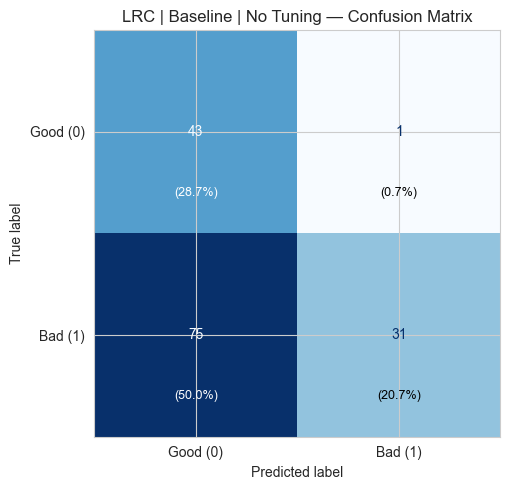

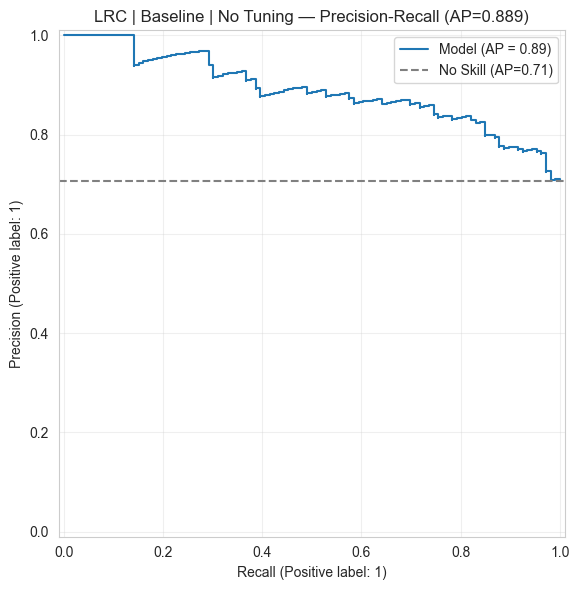

In [14]:
from sklearn.linear_model import LogisticRegression

lrc_baseline_pipe = build_baseline_pipeline(
    LogisticRegression(random_state=config.random_state, class_weight="balanced"),
    use_smote=True,
    smote_type="smote",
)

_, lrc_baseline_pipe = run_experiment(
    lrc_baseline_pipe, X_train, y_train, X_val, y_val,
    name="LRC | Baseline | No Tuning",
    tune=False,
)

### 3.2 LRC — Baseline + Tuning


🔬 LRC | Baseline | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7833
   Best params:
     model__C: 0.10128638050648806
     model__class_weight: None
     model__max_iter: 3773
     model__penalty: l2
     model__solver: liblinear
     smote__k_neighbors: 5
     smote__sampling_strategy: 0.707884483922973
🎯 Optimal threshold: 0.72 (cost: 78)

📊 Validation Metrics (threshold=0.72):
                roc_auc: 0.7935
               accuracy: 0.6133
                     f1: 0.6463
              precision: 0.9138
                 recall: 0.5000
      average_precision: 0.9001
                   cost: 78.0000
               avg_cost: 0.5200
✅ Best CV ROC AUC: 0.7833
   Best params:
     model__C: 0.10128638050648806
     model__class_weight: None
     model__max_iter: 3773
     model__penalty: l2
     model__solver: liblinear
     smote__k_neighbors: 5
     smote__sampling_strategy: 0.707884483922973
🎯 Optimal threshold: 0.72 (cost: 78)

📊 Validation Metrics (thres

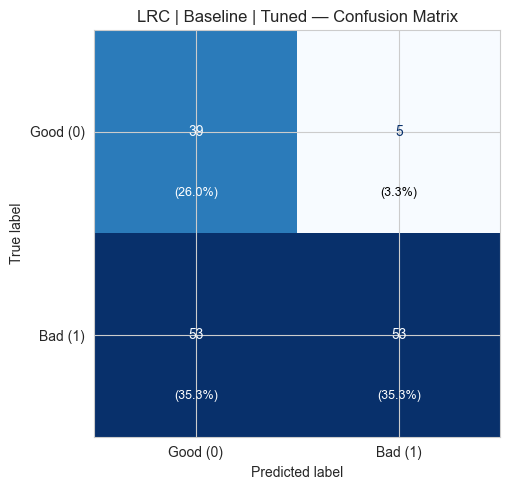

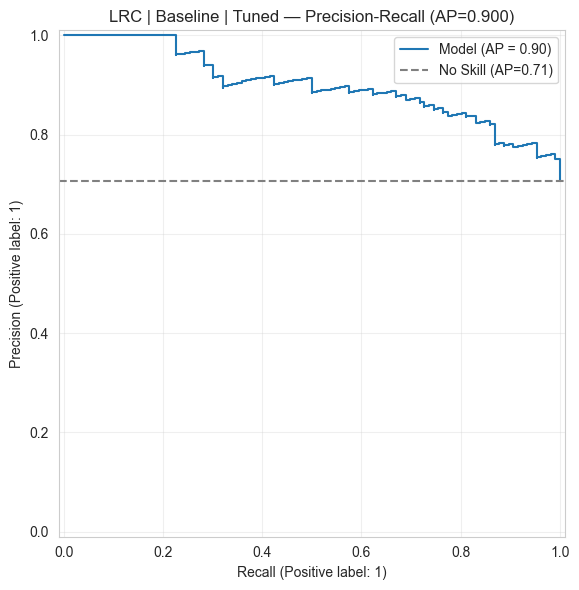

In [15]:
from skopt.space import Categorical, Integer, Real

lrc_baseline_pipe_tune = build_baseline_pipeline(
    LogisticRegression(random_state=config.random_state, class_weight="balanced"),
    use_smote=True,
    smote_type="smote",
)

lrc_baseline_space = {
    "model__C": Real(0.1, 20, prior="log-uniform"),
    "model__penalty": Categorical(["l2"]),
    "model__solver": Categorical(["liblinear"]),
    "model__max_iter": Integer(2000, 10000),
    "model__class_weight": Categorical(["balanced", None]),
    "smote__k_neighbors": Integer(3, 10),
    "smote__sampling_strategy": Real(0.5, 1.0, prior="uniform"),
}

_, lrc_baseline_pipe_tune = run_experiment(
    lrc_baseline_pipe_tune, X_train, y_train, X_val, y_val,
    name="LRC | Baseline | Tuned",
    tune=True,
    search_space=lrc_baseline_space,
    bayes_n_iter=config.models["lrc"].bayes_n_iter,
    bayes_n_points=config.models["lrc"].bayes_n_points,
    cv_folds=config.models["lrc"].cv_folds,
)

### 3.3 LRC — FeatureEngineer + No Tuning


🔬 LRC | FeatureEngineer | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.73 (cost: 67)

📊 Validation Metrics (threshold=0.73):
                roc_auc: 0.7717
               accuracy: 0.5800
                     f1: 0.5828
              precision: 0.9778
                 recall: 0.4151
      average_precision: 0.9039
                   cost: 67.0000
               avg_cost: 0.4467


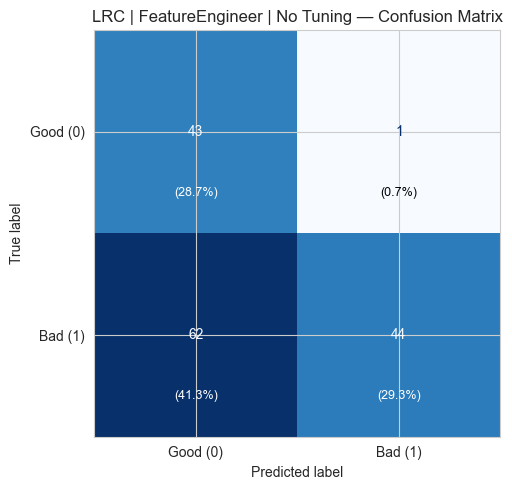

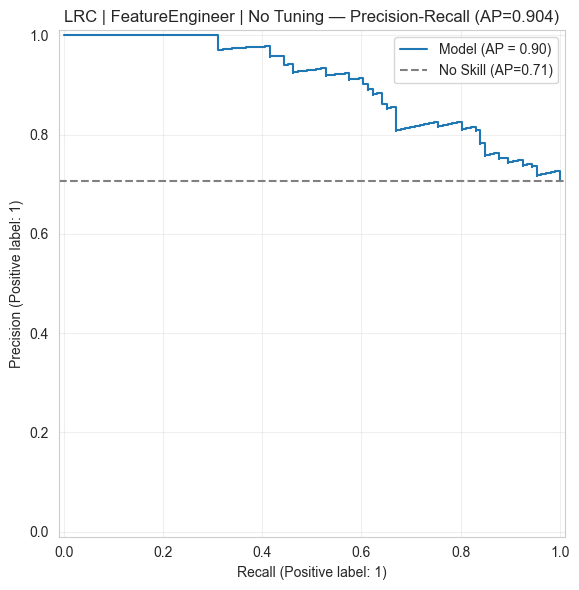

In [16]:
# Use the production pipeline builder — FeatureEngineer + config-driven encoders + SMOTE
lrc_cfg = config.models["lrc"]
lrc_fe_pipe = build_pipeline(
    LogisticRegression(random_state=config.random_state, class_weight="balanced"),
    lrc_cfg,
)

_, lrc_fe_pipe = run_experiment(
    lrc_fe_pipe, X_train, y_train, X_val, y_val,
    name="LRC | FeatureEngineer | No Tuning",
    tune=False,
)

### 3.4 LRC — FeatureEngineer + Tuning


🔬 LRC | FeatureEngineer | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7885
   Best params:
     model__C: 0.10130074372959755
     model__class_weight: None
     model__max_iter: 2753
     model__penalty: l2
     model__solver: liblinear
     smote__k_neighbors: 3
     smote__sampling_strategy: 0.7077132770122381
🎯 Optimal threshold: 0.74 (cost: 69)

📊 Validation Metrics (threshold=0.74):
                roc_auc: 0.7699
               accuracy: 0.6200
                     f1: 0.6460
              precision: 0.9455
                 recall: 0.4906
      average_precision: 0.8992
                   cost: 69.0000
               avg_cost: 0.4600
✅ Best CV ROC AUC: 0.7885
   Best params:
     model__C: 0.10130074372959755
     model__class_weight: None
     model__max_iter: 2753
     model__penalty: l2
     model__solver: liblinear
     smote__k_neighbors: 3
     smote__sampling_strategy: 0.7077132770122381
🎯 Optimal threshold: 0.74 (cost: 69)

📊 Validation Metri

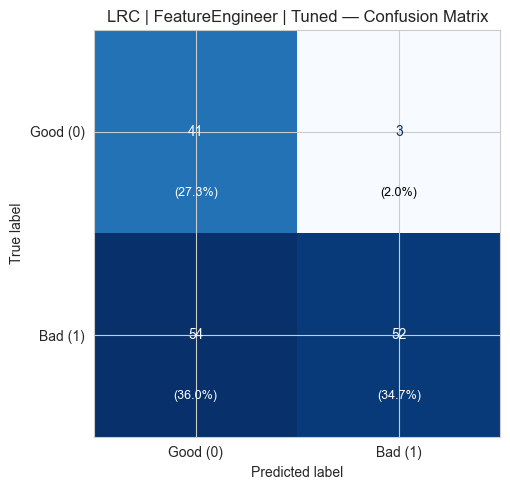

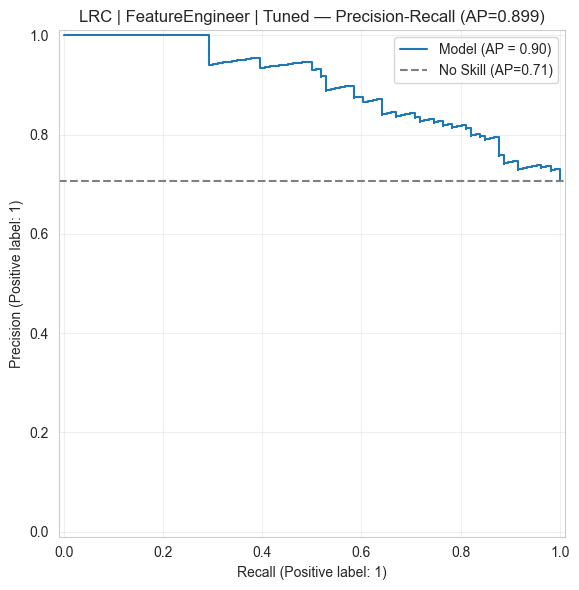

In [17]:
lrc_fe_pipe_tune = build_pipeline(
    LogisticRegression(random_state=config.random_state, class_weight="balanced"),
    lrc_cfg,
)

# Same search space as LRCTrainer.get_search_space()
lrc_fe_space = {
    "model__C": Real(0.1, 20, prior="log-uniform"),
    "model__penalty": Categorical(["l2"]),
    "model__solver": Categorical(["liblinear"]),
    "model__max_iter": Integer(2000, 10000),
    "model__class_weight": Categorical(["balanced", None]),
    "smote__k_neighbors": Integer(3, 10),
    "smote__sampling_strategy": Real(0.5, 1.0, prior="uniform"),
}

_, lrc_fe_pipe_tune = run_experiment(
    lrc_fe_pipe_tune, X_train, y_train, X_val, y_val,
    name="LRC | FeatureEngineer | Tuned",
    tune=True,
    search_space=lrc_fe_space,
    bayes_n_iter=lrc_cfg.bayes_n_iter,
    bayes_n_points=lrc_cfg.bayes_n_points,
    cv_folds=lrc_cfg.cv_folds,
)

---
## 4. Random Forest (RFC)

**Config:** `class_weight={0:1, 1:5}` (cost-sensitive), no SMOTE, BayesSearchCV over tree structure params.

Four experiments:
1. Baseline + No Tuning
2. Baseline + Tuning
3. FeatureEngineer + No Tuning  
4. FeatureEngineer + Tuning

### 4.1 RFC — Baseline + No Tuning


🔬 RFC | Baseline | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.68 (cost: 76)

📊 Validation Metrics (threshold=0.68):
                roc_auc: 0.7700
               accuracy: 0.7067
                     f1: 0.7609
              precision: 0.8974
                 recall: 0.6604
      average_precision: 0.8843
                   cost: 76.0000
               avg_cost: 0.5067
✅ Fitted.
🎯 Optimal threshold: 0.68 (cost: 76)

📊 Validation Metrics (threshold=0.68):
                roc_auc: 0.7700
               accuracy: 0.7067
                     f1: 0.7609
              precision: 0.8974
                 recall: 0.6604
      average_precision: 0.8843
                   cost: 76.0000
               avg_cost: 0.5067


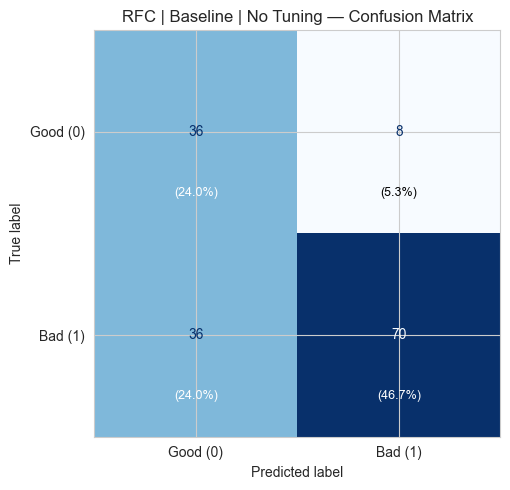

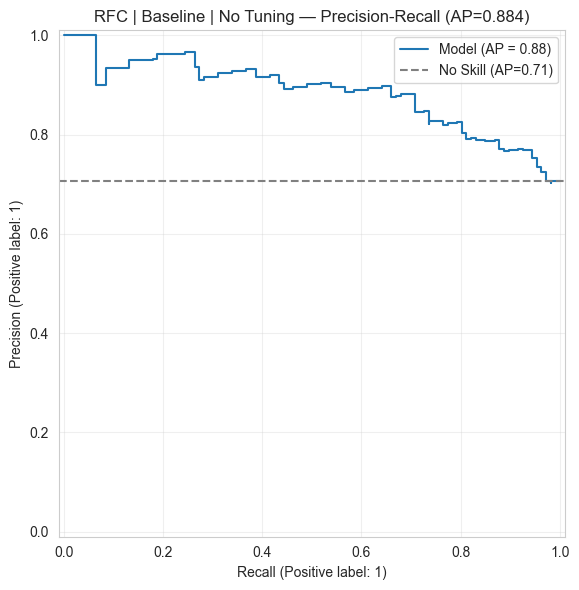

In [18]:
from sklearn.ensemble import RandomForestClassifier

rfc_baseline_pipe = build_baseline_pipeline(
    RandomForestClassifier(
        class_weight={0: 1, 1: 5},
        random_state=config.random_state,
        n_jobs=-1,
    ),
    use_smote=False,
)

_, rfc_baseline_pipe = run_experiment(
    rfc_baseline_pipe, X_train, y_train, X_val, y_val,
    name="RFC | Baseline | No Tuning",
    tune=False,
)

### 4.2 RFC — Baseline + Tuning


🔬 RFC | Baseline | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7713
   Best params:
     model__ccp_alpha: 0.0
     model__criterion: entropy
     model__max_depth: 20
     model__max_features: sqrt
     model__max_samples: 0.9
     model__min_samples_leaf: 10
     model__min_samples_split: 10
     model__n_estimators: 400
🎯 Optimal threshold: 0.92 (cost: 72)

📊 Validation Metrics (threshold=0.92):
                roc_auc: 0.7699
               accuracy: 0.6267
                     f1: 0.6585
              precision: 0.9310
                 recall: 0.5094
      average_precision: 0.8914
                   cost: 72.0000
               avg_cost: 0.4800
✅ Best CV ROC AUC: 0.7713
   Best params:
     model__ccp_alpha: 0.0
     model__criterion: entropy
     model__max_depth: 20
     model__max_features: sqrt
     model__max_samples: 0.9
     model__min_samples_leaf: 10
     model__min_samples_split: 10
     model__n_estimators: 400
🎯 Optimal threshold: 0.92 (co

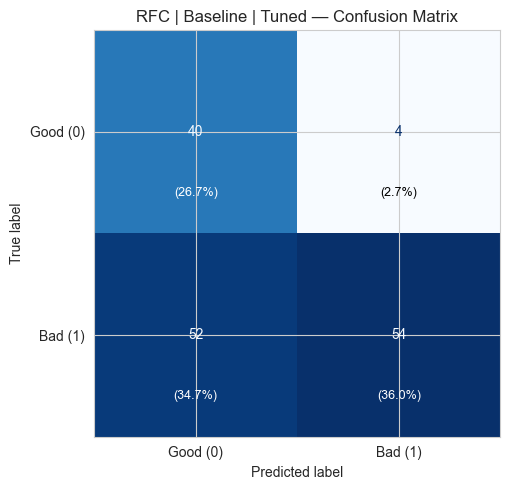

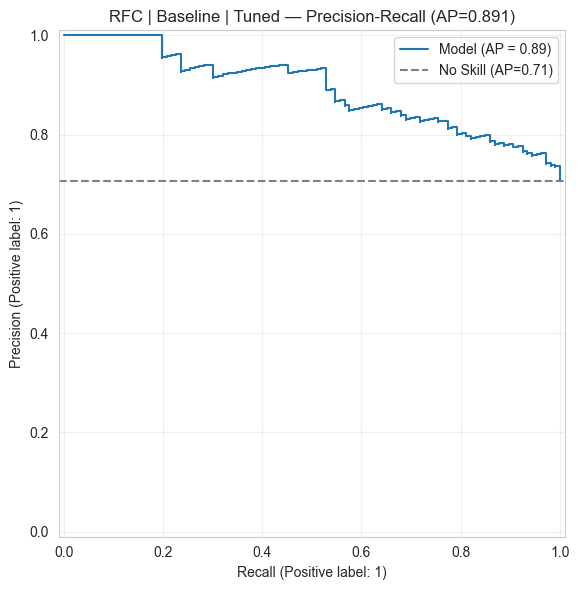

In [19]:
rfc_baseline_pipe_tune = build_baseline_pipeline(
    RandomForestClassifier(
        class_weight={0: 1, 1: 5},
        random_state=config.random_state,
        n_jobs=-1,
    ),
    use_smote=False,
)

rfc_baseline_space = {
    "model__n_estimators": Integer(400, 1200),
    "model__max_depth": Integer(4, 20),
    "model__min_samples_split": Integer(10, 80),
    "model__min_samples_leaf": Integer(10, 40),
    "model__max_features": Categorical(["sqrt", "log2", 0.3, 0.5]),
    "model__max_samples": Real(0.5, 0.9, prior="uniform"),
    "model__ccp_alpha": Real(0.0, 0.02, prior="uniform"),
    "model__criterion": Categorical(["gini", "entropy"]),
}

_, rfc_baseline_pipe_tune = run_experiment(
    rfc_baseline_pipe_tune, X_train, y_train, X_val, y_val,
    name="RFC | Baseline | Tuned",
    tune=True,
    search_space=rfc_baseline_space,
    bayes_n_iter=config.models["rfc"].bayes_n_iter,
    bayes_n_points=config.models["rfc"].bayes_n_points,
    cv_folds=config.models["rfc"].cv_folds,
)

### 4.3 RFC — FeatureEngineer + No Tuning


🔬 RFC | FeatureEngineer | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.63 (cost: 79)

📊 Validation Metrics (threshold=0.63):
                roc_auc: 0.7873
               accuracy: 0.7400
                     f1: 0.7979
              precision: 0.8851
                 recall: 0.7264
      average_precision: 0.8897
                   cost: 79.0000
               avg_cost: 0.5267
✅ Fitted.
🎯 Optimal threshold: 0.63 (cost: 79)

📊 Validation Metrics (threshold=0.63):
                roc_auc: 0.7873
               accuracy: 0.7400
                     f1: 0.7979
              precision: 0.8851
                 recall: 0.7264
      average_precision: 0.8897
                   cost: 79.0000
               avg_cost: 0.5267


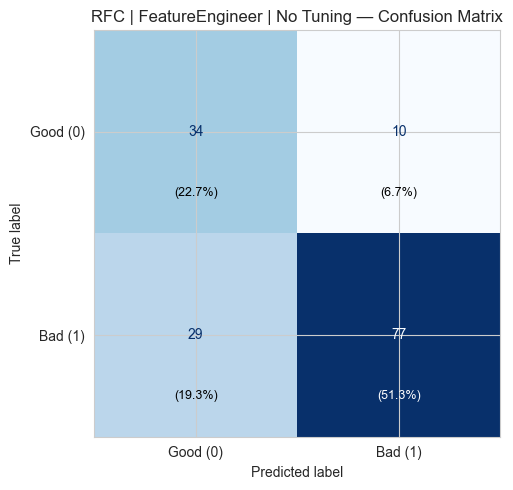

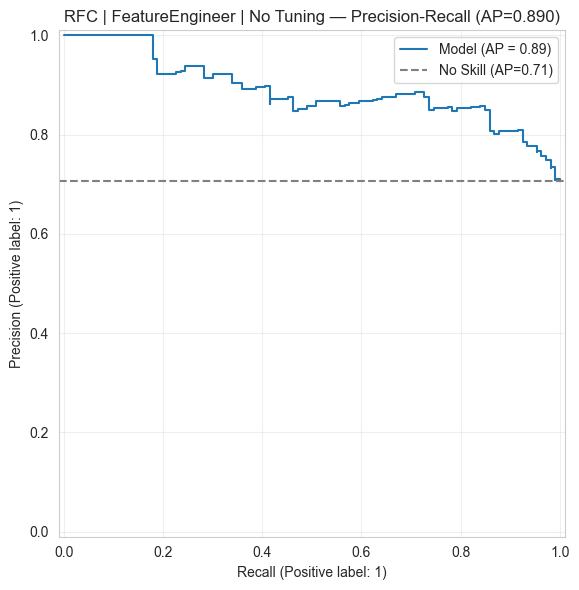

In [20]:
rfc_cfg = config.models["rfc"]
rfc_fe_pipe = build_pipeline(
    RandomForestClassifier(
        class_weight=rfc_cfg.class_weight or {0: 1, 1: 5},
        random_state=config.random_state,
        n_jobs=-1,
    ),
    rfc_cfg,
)

_, rfc_fe_pipe = run_experiment(
    rfc_fe_pipe, X_train, y_train, X_val, y_val,
    name="RFC | FeatureEngineer | No Tuning",
    tune=False,
)

### 4.4 RFC — FeatureEngineer + Tuning


🔬 RFC | FeatureEngineer | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7876
   Best params:
     model__ccp_alpha: 0.0
     model__criterion: entropy
     model__max_depth: 20
     model__max_features: log2
     model__max_samples: 0.5
     model__min_samples_leaf: 10
     model__min_samples_split: 10
     model__n_estimators: 400
🎯 Optimal threshold: 0.90 (cost: 80)

📊 Validation Metrics (threshold=0.90):
                roc_auc: 0.7822
               accuracy: 0.6800
                     f1: 0.7333
              precision: 0.8919
                 recall: 0.6226
      average_precision: 0.8888
                   cost: 80.0000
               avg_cost: 0.5333
✅ Best CV ROC AUC: 0.7876
   Best params:
     model__ccp_alpha: 0.0
     model__criterion: entropy
     model__max_depth: 20
     model__max_features: log2
     model__max_samples: 0.5
     model__min_samples_leaf: 10
     model__min_samples_split: 10
     model__n_estimators: 400
🎯 Optimal threshold: 0

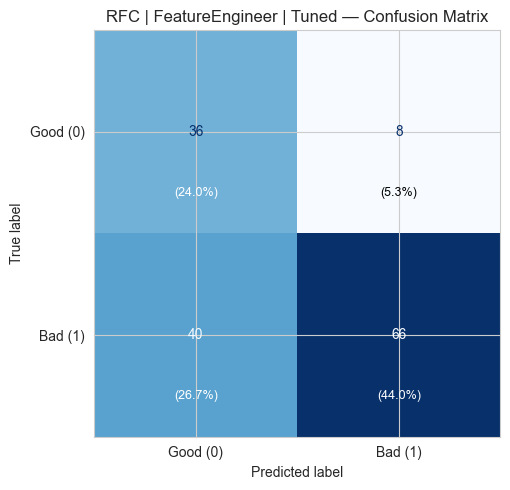

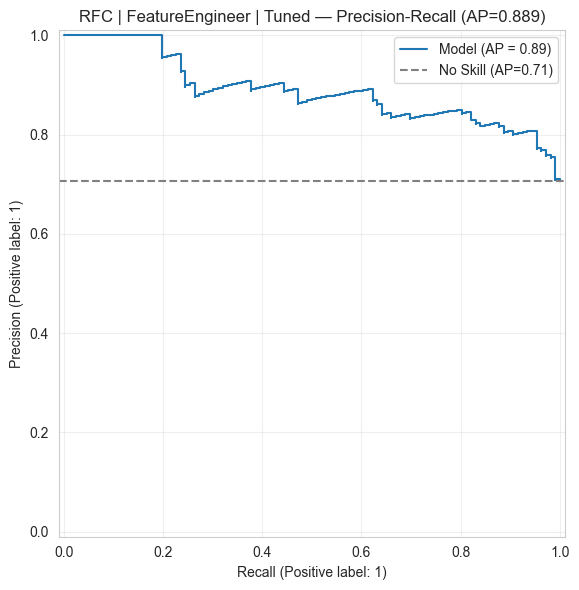

In [21]:
rfc_fe_pipe_tune = build_pipeline(
    RandomForestClassifier(
        class_weight=rfc_cfg.class_weight or {0: 1, 1: 5},
        random_state=config.random_state,
        n_jobs=-1,
    ),
    rfc_cfg,
)

# Same search space as RFTrainer.get_search_space()
rfc_fe_space = {
    "model__n_estimators": Integer(400, 1200),
    "model__max_depth": Integer(4, 20),
    "model__min_samples_split": Integer(10, 80),
    "model__min_samples_leaf": Integer(10, 40),
    "model__max_features": Categorical(["sqrt", "log2", 0.3, 0.5]),
    "model__max_samples": Real(0.5, 0.9, prior="uniform"),
    "model__ccp_alpha": Real(0.0, 0.02, prior="uniform"),
    "model__criterion": Categorical(["gini", "entropy"]),
}

_, rfc_fe_pipe_tune = run_experiment(
    rfc_fe_pipe_tune, X_train, y_train, X_val, y_val,
    name="RFC | FeatureEngineer | Tuned",
    tune=True,
    search_space=rfc_fe_space,
    bayes_n_iter=rfc_cfg.bayes_n_iter,
    bayes_n_points=rfc_cfg.bayes_n_points,
    cv_folds=rfc_cfg.cv_folds,
)

---
## 5. Support Vector Classifier (SVC)

**Config:** `probability=True`, SVMSMOTE oversampling, BayesSearchCV over C, gamma, kernel, tol + smote params.

Four experiments:
1. Baseline + No Tuning
2. Baseline + Tuning
3. FeatureEngineer + No Tuning
4. FeatureEngineer + Tuning

### 5.1 SVC — Baseline + No Tuning


🔬 SVC | Baseline | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.73 (cost: 81)

📊 Validation Metrics (threshold=0.73):
                roc_auc: 0.7702
               accuracy: 0.6733
                     f1: 0.7263
              precision: 0.8904
                 recall: 0.6132
      average_precision: 0.8884
                   cost: 81.0000
               avg_cost: 0.5400
✅ Fitted.
🎯 Optimal threshold: 0.73 (cost: 81)

📊 Validation Metrics (threshold=0.73):
                roc_auc: 0.7702
               accuracy: 0.6733
                     f1: 0.7263
              precision: 0.8904
                 recall: 0.6132
      average_precision: 0.8884
                   cost: 81.0000
               avg_cost: 0.5400


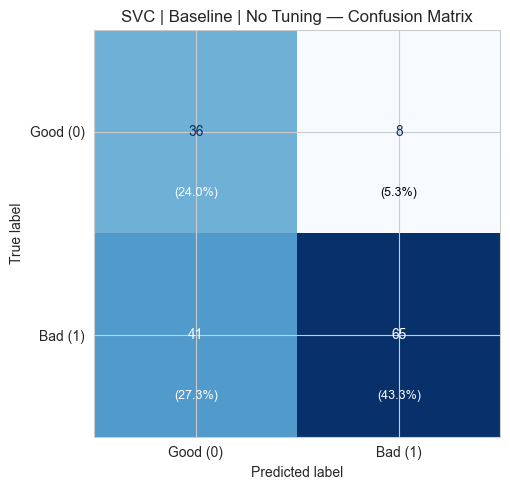

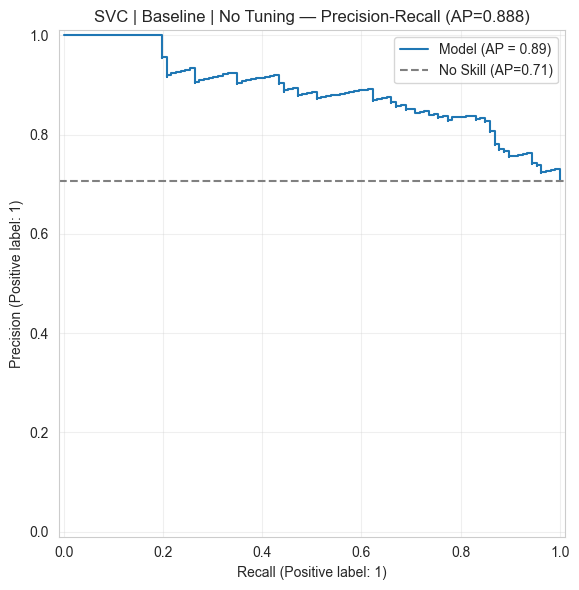

In [22]:
from sklearn.svm import SVC

svc_baseline_pipe = build_baseline_pipeline(
    SVC(probability=True, random_state=config.random_state),
    use_smote=True,
    smote_type="svmsmote",
)

_, svc_baseline_pipe = run_experiment(
    svc_baseline_pipe, X_train, y_train, X_val, y_val,
    name="SVC | Baseline | No Tuning",
    tune=False,
)

### 5.2 SVC — Baseline + Tuning


🔬 SVC | Baseline | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7764
   Best params:
     model__C: 3.2029495399717702
     model__gamma: 0.0035550108868276915
     model__kernel: linear
     model__tol: 0.02156775125711919
     smote__k_neighbors: 4
     smote__sampling_strategy: 0.5669423780737548
🎯 Optimal threshold: 0.73 (cost: 82)

📊 Validation Metrics (threshold=0.73):
                roc_auc: 0.7657
               accuracy: 0.6400
                     f1: 0.6860
              precision: 0.8939
                 recall: 0.5566
      average_precision: 0.8872
                   cost: 82.0000
               avg_cost: 0.5467
✅ Best CV ROC AUC: 0.7764
   Best params:
     model__C: 3.2029495399717702
     model__gamma: 0.0035550108868276915
     model__kernel: linear
     model__tol: 0.02156775125711919
     smote__k_neighbors: 4
     smote__sampling_strategy: 0.5669423780737548
🎯 Optimal threshold: 0.73 (cost: 82)

📊 Validation Metrics (threshold=0.73):
  

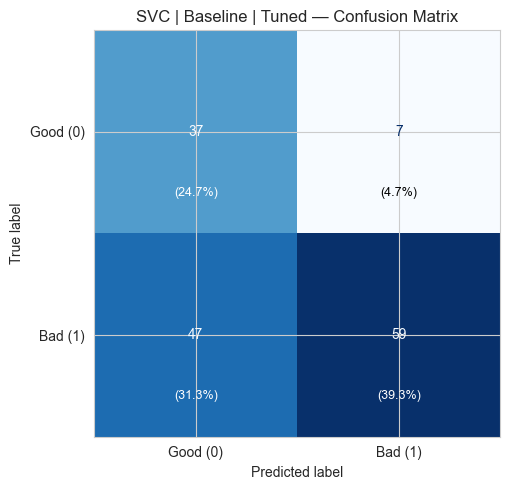

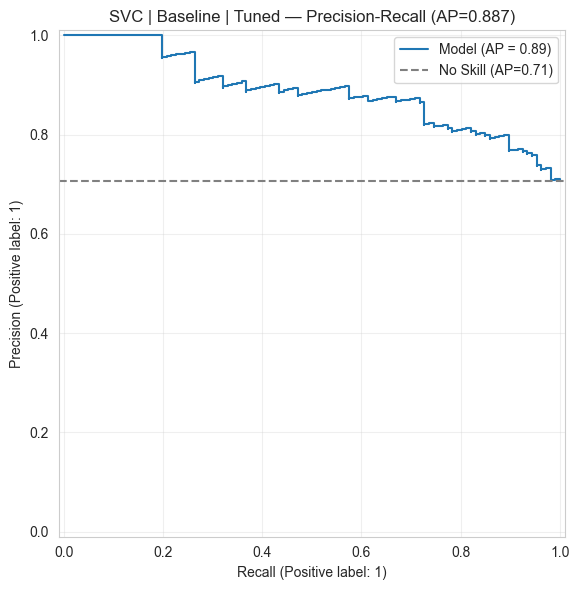

In [23]:
svc_baseline_pipe_tune = build_baseline_pipeline(
    SVC(probability=True, random_state=config.random_state),
    use_smote=True,
    smote_type="svmsmote",
)

svc_baseline_space = {
    "model__C": Real(1, 15, prior="uniform"),
    "model__gamma": Real(1e-5, 1, prior="log-uniform"),
    "model__kernel": Categorical(["rbf", "linear"]),
    "model__tol": Real(1e-4, 1e-1, prior="log-uniform"),
    "smote__k_neighbors": Integer(2, 7),
    "smote__sampling_strategy": Real(0.5, 0.9, prior="uniform"),
}

_, svc_baseline_pipe_tune = run_experiment(
    svc_baseline_pipe_tune, X_train, y_train, X_val, y_val,
    name="SVC | Baseline | Tuned",
    tune=True,
    search_space=svc_baseline_space,
    bayes_n_iter=config.models["svc"].bayes_n_iter,
    bayes_n_points=config.models["svc"].bayes_n_points,
    cv_folds=config.models["svc"].cv_folds,
)

### 5.3 SVC — FeatureEngineer + No Tuning


🔬 SVC | FeatureEngineer | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.87 (cost: 80)

📊 Validation Metrics (threshold=0.87):
                roc_auc: 0.7736
               accuracy: 0.4933
                     f1: 0.4493
              precision: 0.9688
                 recall: 0.2925
      average_precision: 0.8925
                   cost: 80.0000
               avg_cost: 0.5333

📊 Validation Metrics (threshold=0.87):
                roc_auc: 0.7736
               accuracy: 0.4933
                     f1: 0.4493
              precision: 0.9688
                 recall: 0.2925
      average_precision: 0.8925
                   cost: 80.0000
               avg_cost: 0.5333


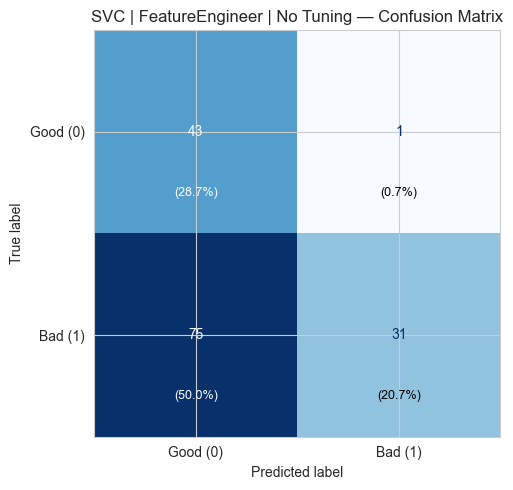

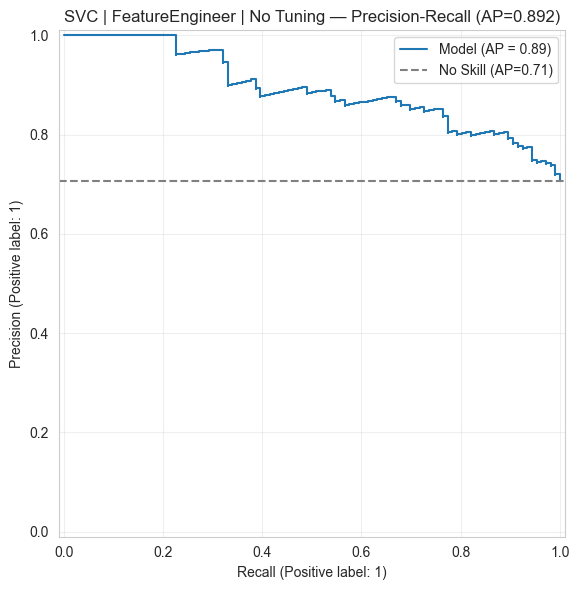

In [24]:
svc_cfg = config.models["svc"]
svc_fe_pipe = build_pipeline(
    SVC(probability=True, random_state=config.random_state),
    svc_cfg,
)

_, svc_fe_pipe = run_experiment(
    svc_fe_pipe, X_train, y_train, X_val, y_val,
    name="SVC | FeatureEngineer | No Tuning",
    tune=False,
)

### 5.4 SVC — FeatureEngineer + Tuning


🔬 SVC | FeatureEngineer | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7987
   Best params:
     model__C: 7.559949951771714
     model__gamma: 0.0047486674858173965
     model__kernel: rbf
     model__tol: 0.027566163348359245
     smote__k_neighbors: 6
     smote__sampling_strategy: 0.6382823814868854
🎯 Optimal threshold: 0.69 (cost: 67)

📊 Validation Metrics (threshold=0.69):
                roc_auc: 0.8109
               accuracy: 0.7133
                     f1: 0.7624
              precision: 0.9200
                 recall: 0.6509
      average_precision: 0.9042
                   cost: 67.0000
               avg_cost: 0.4467
✅ Best CV ROC AUC: 0.7987
   Best params:
     model__C: 7.559949951771714
     model__gamma: 0.0047486674858173965
     model__kernel: rbf
     model__tol: 0.027566163348359245
     smote__k_neighbors: 6
     smote__sampling_strategy: 0.6382823814868854
🎯 Optimal threshold: 0.69 (cost: 67)

📊 Validation Metrics (threshold=0.69):
 

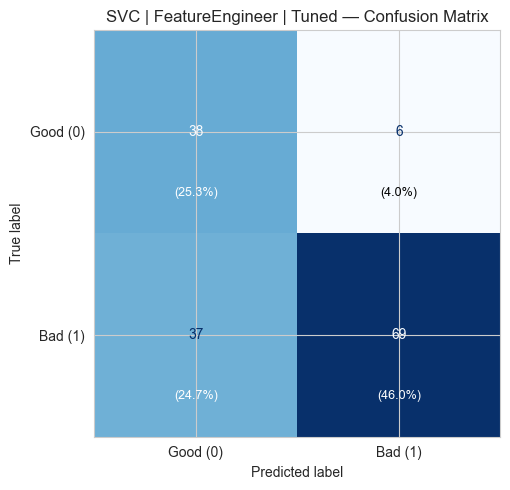

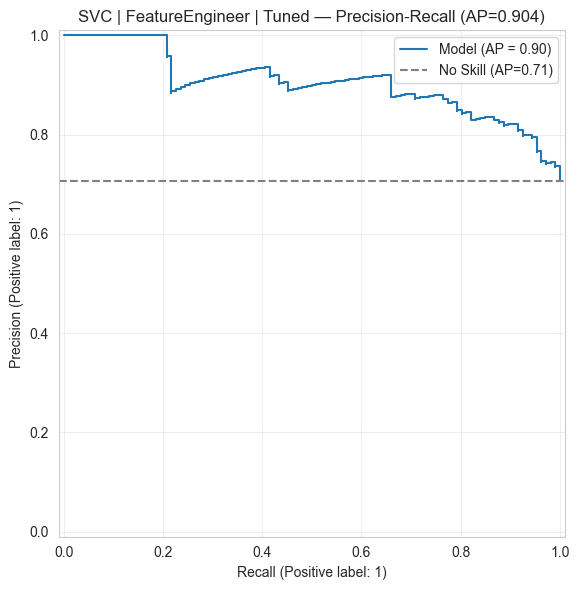

In [25]:
svc_fe_pipe_tune = build_pipeline(
    SVC(probability=True, random_state=config.random_state),
    svc_cfg,
)

# Same search space as SVCTrainer.get_search_space()
svc_fe_space = {
    "model__C": Real(1, 15, prior="uniform"),
    "model__gamma": Real(1e-5, 1, prior="log-uniform"),
    "model__kernel": Categorical(["rbf", "linear"]),
    "model__tol": Real(1e-4, 1e-1, prior="log-uniform"),
    "smote__k_neighbors": Integer(2, 7),
    "smote__sampling_strategy": Real(0.5, 0.9, prior="uniform"),
}

_, svc_fe_pipe_tune = run_experiment(
    svc_fe_pipe_tune, X_train, y_train, X_val, y_val,
    name="SVC | FeatureEngineer | Tuned",
    tune=True,
    search_space=svc_fe_space,
    bayes_n_iter=svc_cfg.bayes_n_iter,
    bayes_n_points=svc_cfg.bayes_n_points,
    cv_folds=svc_cfg.cv_folds,
)

---
## 6. CatBoost

**Config:** `scale_pos_weight=5.0` (cost-sensitive), native categorical handling (no one-hot encoding), BayesSearchCV over depth, learning_rate, iterations, l2_leaf_reg, border_count.

CatBoost is special — it uses its own internal encoding for categoricals via `cat_features` indices. The pipeline uses `build_catboost_pipeline()` / our custom `build_baseline_catboost_pipeline()` instead of the standard `build_pipeline()`.

Four experiments:
1. Baseline + No Tuning
2. Baseline + Tuning
3. FeatureEngineer + No Tuning
4. FeatureEngineer + Tuning

### 6.1 CatBoost — Baseline + No Tuning


🔬 CatBoost | Baseline | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.97 (cost: 67)

📊 Validation Metrics (threshold=0.97):
                roc_auc: 0.8098
               accuracy: 0.6067
                     f1: 0.6242
              precision: 0.9608
                 recall: 0.4623
      average_precision: 0.9103
                   cost: 67.0000
               avg_cost: 0.4467
✅ Fitted.
🎯 Optimal threshold: 0.97 (cost: 67)

📊 Validation Metrics (threshold=0.97):
                roc_auc: 0.8098
               accuracy: 0.6067
                     f1: 0.6242
              precision: 0.9608
                 recall: 0.4623
      average_precision: 0.9103
                   cost: 67.0000
               avg_cost: 0.4467


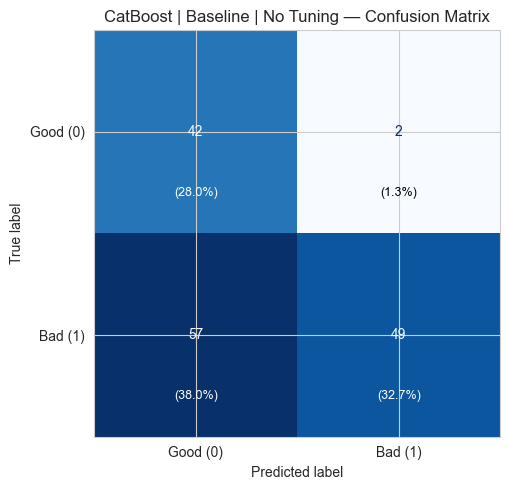

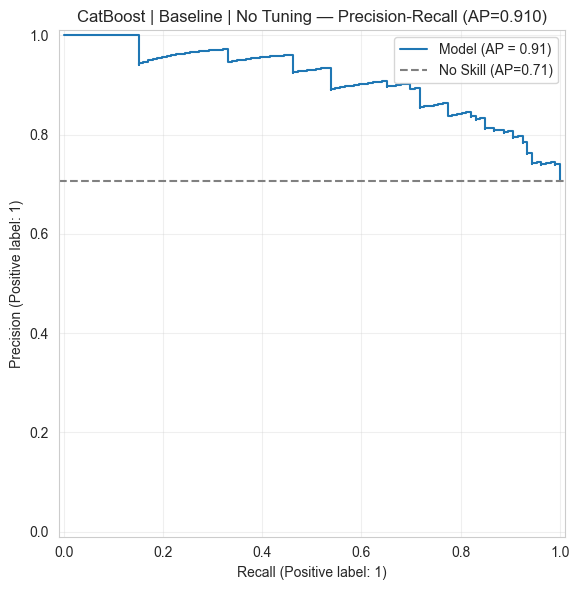

In [26]:
cat_baseline_pipe = build_baseline_catboost_pipeline()

_, cat_baseline_pipe = run_experiment(
    cat_baseline_pipe, X_train, y_train, X_val, y_val,
    name="CatBoost | Baseline | No Tuning",
    tune=False,
)

### 6.2 CatBoost — Baseline + Tuning


🔬 CatBoost | Baseline | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7837
   Best params:
     model__border_count: 240
     model__depth: 6
     model__iterations: 367
     model__l2_leaf_reg: 7.906841398538139
     model__learning_rate: 0.07913379882073368
🎯 Optimal threshold: 0.91 (cost: 78)

📊 Validation Metrics (threshold=0.91):
                roc_auc: 0.7925
               accuracy: 0.6933
                     f1: 0.7473
              precision: 0.8947
                 recall: 0.6415
      average_precision: 0.8996
                   cost: 78.0000
               avg_cost: 0.5200
✅ Best CV ROC AUC: 0.7837
   Best params:
     model__border_count: 240
     model__depth: 6
     model__iterations: 367
     model__l2_leaf_reg: 7.906841398538139
     model__learning_rate: 0.07913379882073368
🎯 Optimal threshold: 0.91 (cost: 78)

📊 Validation Metrics (threshold=0.91):
                roc_auc: 0.7925
               accuracy: 0.6933
                     f1: 0.

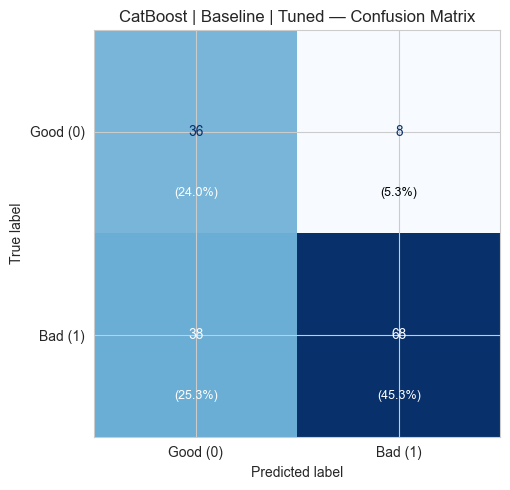

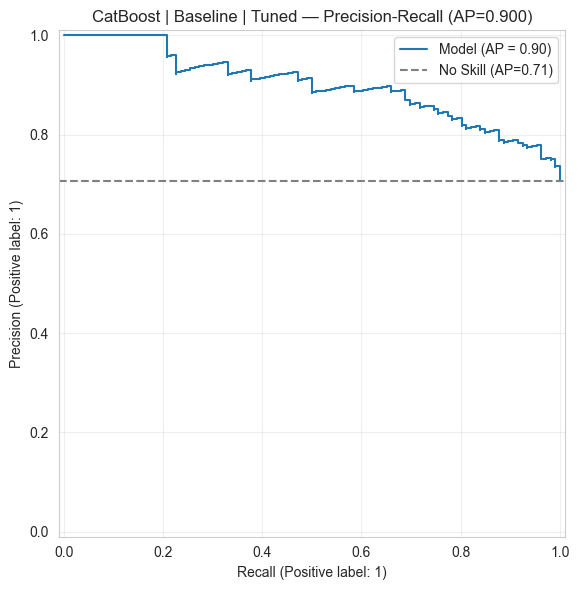

In [27]:
cat_baseline_pipe_tune = build_baseline_catboost_pipeline()

# Same search space as CatBoostTrainer.get_search_space()
cat_baseline_space = {
    "model__depth": Integer(4, 10),
    "model__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "model__iterations": Integer(200, 1200),
    "model__l2_leaf_reg": Real(1.0, 10.0, prior="log-uniform"),
    "model__border_count": Integer(30, 300),
}

_, cat_baseline_pipe_tune = run_experiment(
    cat_baseline_pipe_tune, X_train, y_train, X_val, y_val,
    name="CatBoost | Baseline | Tuned",
    tune=True,
    search_space=cat_baseline_space,
    bayes_n_iter=config.models["cat"].bayes_n_iter,
    bayes_n_points=config.models["cat"].bayes_n_points,
    cv_folds=config.models["cat"].cv_folds,
)

### 6.3 CatBoost — FeatureEngineer + No Tuning


🔬 CatBoost | FeatureEngineer | No Tuning
⏳ Fitting with default parameters...
✅ Fitted.
🎯 Optimal threshold: 0.93 (cost: 74)

📊 Validation Metrics (threshold=0.93):
                roc_auc: 0.7742
               accuracy: 0.6933
                     f1: 0.7444
              precision: 0.9054
                 recall: 0.6321
      average_precision: 0.8853
                   cost: 74.0000
               avg_cost: 0.4933
✅ Fitted.
🎯 Optimal threshold: 0.93 (cost: 74)

📊 Validation Metrics (threshold=0.93):
                roc_auc: 0.7742
               accuracy: 0.6933
                     f1: 0.7444
              precision: 0.9054
                 recall: 0.6321
      average_precision: 0.8853
                   cost: 74.0000
               avg_cost: 0.4933


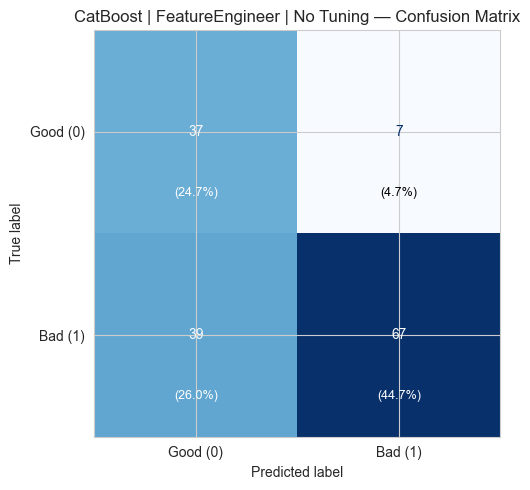

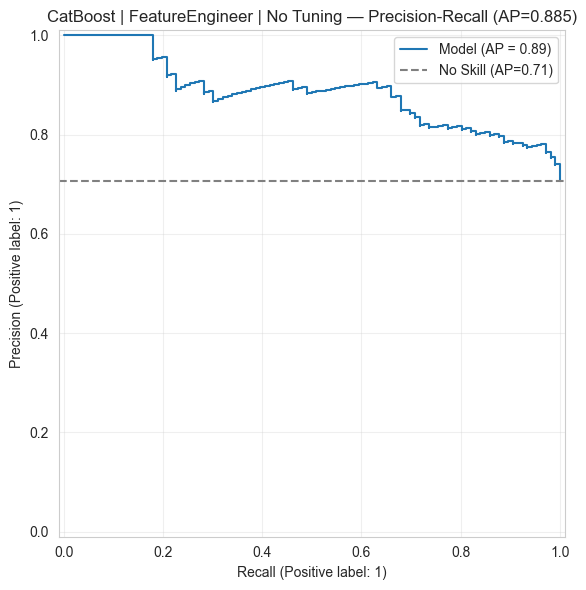

In [28]:
# Use the production CatBoost pipeline builder (FeatureEngineer + passthrough selector + CatBoostWrapper)
cat_cfg = config.models["cat"]
cat_fe_pipe = build_catboost_pipeline(
    model_cfg=cat_cfg,
    random_state=config.random_state,
    scale_pos_weight=cat_cfg.scale_pos_weight or 5.0,
)

_, cat_fe_pipe = run_experiment(
    cat_fe_pipe, X_train, y_train, X_val, y_val,
    name="CatBoost | FeatureEngineer | No Tuning",
    tune=False,
)

### 6.4 CatBoost — FeatureEngineer + Tuning


🔬 CatBoost | FeatureEngineer | Tuned
⏳ Running BayesSearchCV (n_iter=20, cv=8)...
✅ Best CV ROC AUC: 0.7914
   Best params:
     model__border_count: 231
     model__depth: 10
     model__iterations: 200
     model__l2_leaf_reg: 6.04872540684508
     model__learning_rate: 0.29999999999999993
🎯 Optimal threshold: 0.93 (cost: 77)

📊 Validation Metrics (threshold=0.93):
                roc_auc: 0.7725
               accuracy: 0.7267
                     f1: 0.7831
              precision: 0.8916
                 recall: 0.6981
      average_precision: 0.8787
                   cost: 77.0000
               avg_cost: 0.5133
✅ Best CV ROC AUC: 0.7914
   Best params:
     model__border_count: 231
     model__depth: 10
     model__iterations: 200
     model__l2_leaf_reg: 6.04872540684508
     model__learning_rate: 0.29999999999999993
🎯 Optimal threshold: 0.93 (cost: 77)

📊 Validation Metrics (threshold=0.93):
                roc_auc: 0.7725
               accuracy: 0.7267
                    

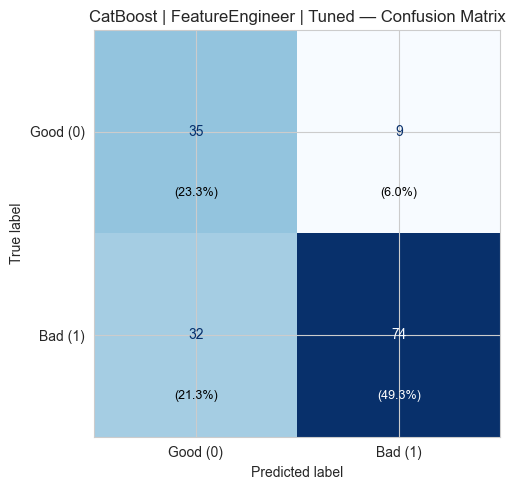

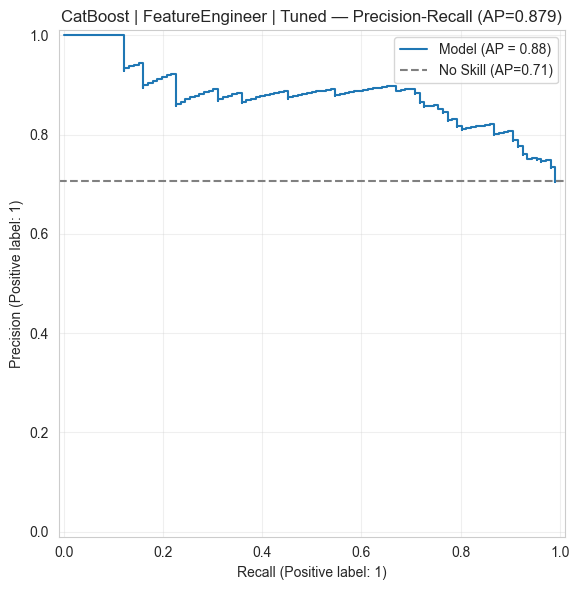

In [29]:
cat_fe_pipe_tune = build_catboost_pipeline(
    model_cfg=cat_cfg,
    random_state=config.random_state,
    scale_pos_weight=cat_cfg.scale_pos_weight or 5.0,
)

cat_fe_space = {
    "model__depth": Integer(4, 10),
    "model__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "model__iterations": Integer(200, 1200),
    "model__l2_leaf_reg": Real(1.0, 10.0, prior="log-uniform"),
    "model__border_count": Integer(30, 300),
}

_, cat_fe_pipe_tune = run_experiment(
    cat_fe_pipe_tune, X_train, y_train, X_val, y_val,
    name="CatBoost | FeatureEngineer | Tuned",
    tune=True,
    search_space=cat_fe_space,
    bayes_n_iter=cat_cfg.bayes_n_iter,
    bayes_n_points=cat_cfg.bayes_n_points,
    cv_folds=cat_cfg.cv_folds,
)

---
## 7. Results Comparison

All 16 experiment results collected in `ALL_RESULTS`. Let's compare them side-by-side, sorted by **total cost** (the project's primary metric: lower = better).

### 🔄 Option: Load Pre-Trained Models from MLflow

If you want to **skip the training phase** (Sections 3–6), you can load the latest registered
versions of all four pipelines from the MLflow model registry. These are the **FeatureEngineer + Tuned**
variants produced by `main.py`.

Run the cell below to load them. If you trained all 16 experiments above, you can **skip** the next cell — the
`ensemble_pipelines` dict will be populated from the notebook-trained pipelines in Section 8.

In [30]:
# ══════════════════════════════════════════════════════════════════════
# 🔄 OPTIONAL: Load pre-trained models from MLflow registry
# ══════════════════════════════════════════════════════════════════════
# Set LOAD_FROM_MLFLOW = True  to skip training and use registered models
# Set LOAD_FROM_MLFLOW = False to use the pipelines trained in Sections 3–6
# ══════════════════════════════════════════════════════════════════════

LOAD_FROM_MLFLOW = False  # ← Change to True to load from MLflow

if LOAD_FROM_MLFLOW:
    import mlflow
    from credit_risk_model.predict import load_pipelines_from_registry

    mlflow.set_tracking_uri(config.mlflow["backend_store_uri"])
    mlflow_pipelines = load_pipelines_from_registry()

    print("=" * 70)
    print("📦 LOADED PIPELINES FROM MLFLOW REGISTRY")
    print("=" * 70)

    client = mlflow.tracking.MlflowClient()
    for key, pipe in mlflow_pipelines.items():
        model_step = pipe.steps[-1][1]
        registry_name = config.models[key].registry_name
        versions = client.search_model_versions(f"name='{registry_name}'")
        latest_ver = max(versions, key=lambda v: int(v.version)) if versions else None
        ver_str = f"v{latest_ver.version}" if latest_ver else "unknown"
        run_id = latest_ver.run_id[:8] if latest_ver else "n/a"
        print(f"   {key.upper():>4s}: {registry_name:<25s}  {ver_str}  "
              f"(run {run_id})  →  {model_step.__class__.__name__}")

    print(f"\n✅ All {len(mlflow_pipelines)} pipelines loaded successfully.")
    print("   These are the FeatureEngineer+Tuned variants trained by main.py.")
    print("\n⚠️  Note: ALL_RESULTS is empty (training was skipped).")
    print("   Section 7 comparison table/charts will be skipped.")
    print("   Jump directly to Section 8 (Ensemble Scoring) below.")
else:
    mlflow_pipelines = None
    print("ℹ️  Using notebook-trained pipelines (Sections 3–6).")
    print("   ALL_RESULTS should contain 16 experiments.")
    print(f"   Current count: {len(ALL_RESULTS)} experiments in ALL_RESULTS.")

ℹ️  Using notebook-trained pipelines (Sections 3–6).
   ALL_RESULTS should contain 16 experiments.
   Current count: 16 experiments in ALL_RESULTS.


In [31]:
if not ALL_RESULTS:
    print("⏭️  No training results — ALL_RESULTS is empty.")
    print("   If you loaded from MLflow, skip to Section 8 (Ensemble Scoring).")
    results_df = pd.DataFrame()
    results_display = pd.DataFrame()
else:
    results_df = pd.DataFrame(ALL_RESULTS)

    # Parse experiment name into components
    parts = results_df["experiment"].str.split(" | ", expand=True)
    results_df["model"] = parts[0]
    results_df["features"] = parts[1]
    results_df["tuning"] = parts[2].fillna("No Tuning")

    # Reorder columns for readability
    display_cols = ["model", "features", "tuning", "threshold", "cost", "avg_cost",
                    "roc_auc", "average_precision", "f1", "precision", "recall", "accuracy"]
    results_display = results_df[display_cols].sort_values("roc_auc", ascending=False).reset_index(drop=True)

    print("=" * 100)
    print("📊 ALL 16 EXPERIMENTS — SORTED BY ROC AUC (higher = better)")
    print("=" * 100)
    print(f"   Cost matrix: FP={config.cost_matrix.false_positive}, FN={config.cost_matrix.false_negative}")
    print(f"   Validation set: n={len(y_val)}\n")

    # Format for display
    styled = results_display.style.format({
        "threshold": "{:.2f}",
        "cost": "{:.0f}",
        "avg_cost": "{:.4f}",
        "roc_auc": "{:.4f}",
        "average_precision": "{:.4f}",
        "f1": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "accuracy": "{:.4f}",
    }).background_gradient(subset=["cost"], cmap="RdYlGn_r").background_gradient(subset=["roc_auc"], cmap="RdYlGn")

    display(styled)

📊 ALL 16 EXPERIMENTS — SORTED BY ROC AUC (higher = better)
   Cost matrix: FP=5.0, FN=1.0
   Validation set: n=150



,model,features,tuning,threshold,cost,avg_cost,roc_auc,average_precision,f1,precision,recall,accuracy
0,SVC,|,FeatureEngineer,0.69,67,0.4467,0.8109,0.9042,0.7624,0.9200,0.6509,0.7133
1,CatBoost,|,Baseline,0.97,67,0.4467,0.8098,0.9103,0.6242,0.9608,0.4623,0.6067
2,LRC,|,Baseline,0.72,78,0.5200,0.7935,0.9001,0.6463,0.9138,0.5000,0.6133
3,CatBoost,|,Baseline,0.91,78,0.5200,0.7925,0.8996,0.7473,0.8947,0.6415,0.6933
4,RFC,|,FeatureEngineer,0.63,79,0.5267,0.7873,0.8897,0.7979,0.8851,0.7264,0.7400
5,RFC,|,FeatureEngineer,0.90,80,0.5333,0.7822,0.8888,0.7333,0.8919,0.6226,0.6800
6,LRC,|,Baseline,0.87,80,0.5333,0.7742,0.8892,0.4493,0.9688,0.2925,0.4933
7,CatBoost,|,FeatureEngineer,0.93,74,0.4933,0.7742,0.8853,0.7444,0.9054,0.6321,0.6933
8,SVC,|,FeatureEngineer,0.87,80,0.5333,0.7736,0.8925,0.4493,0.9688,0.2925,0.4933
9,CatBoost,|,FeatureEngineer,0.93,77,0.5133,0.7725,0.8787,0.7831,0.8916,0.6981,0.7267


### 7.1 Visual Comparison

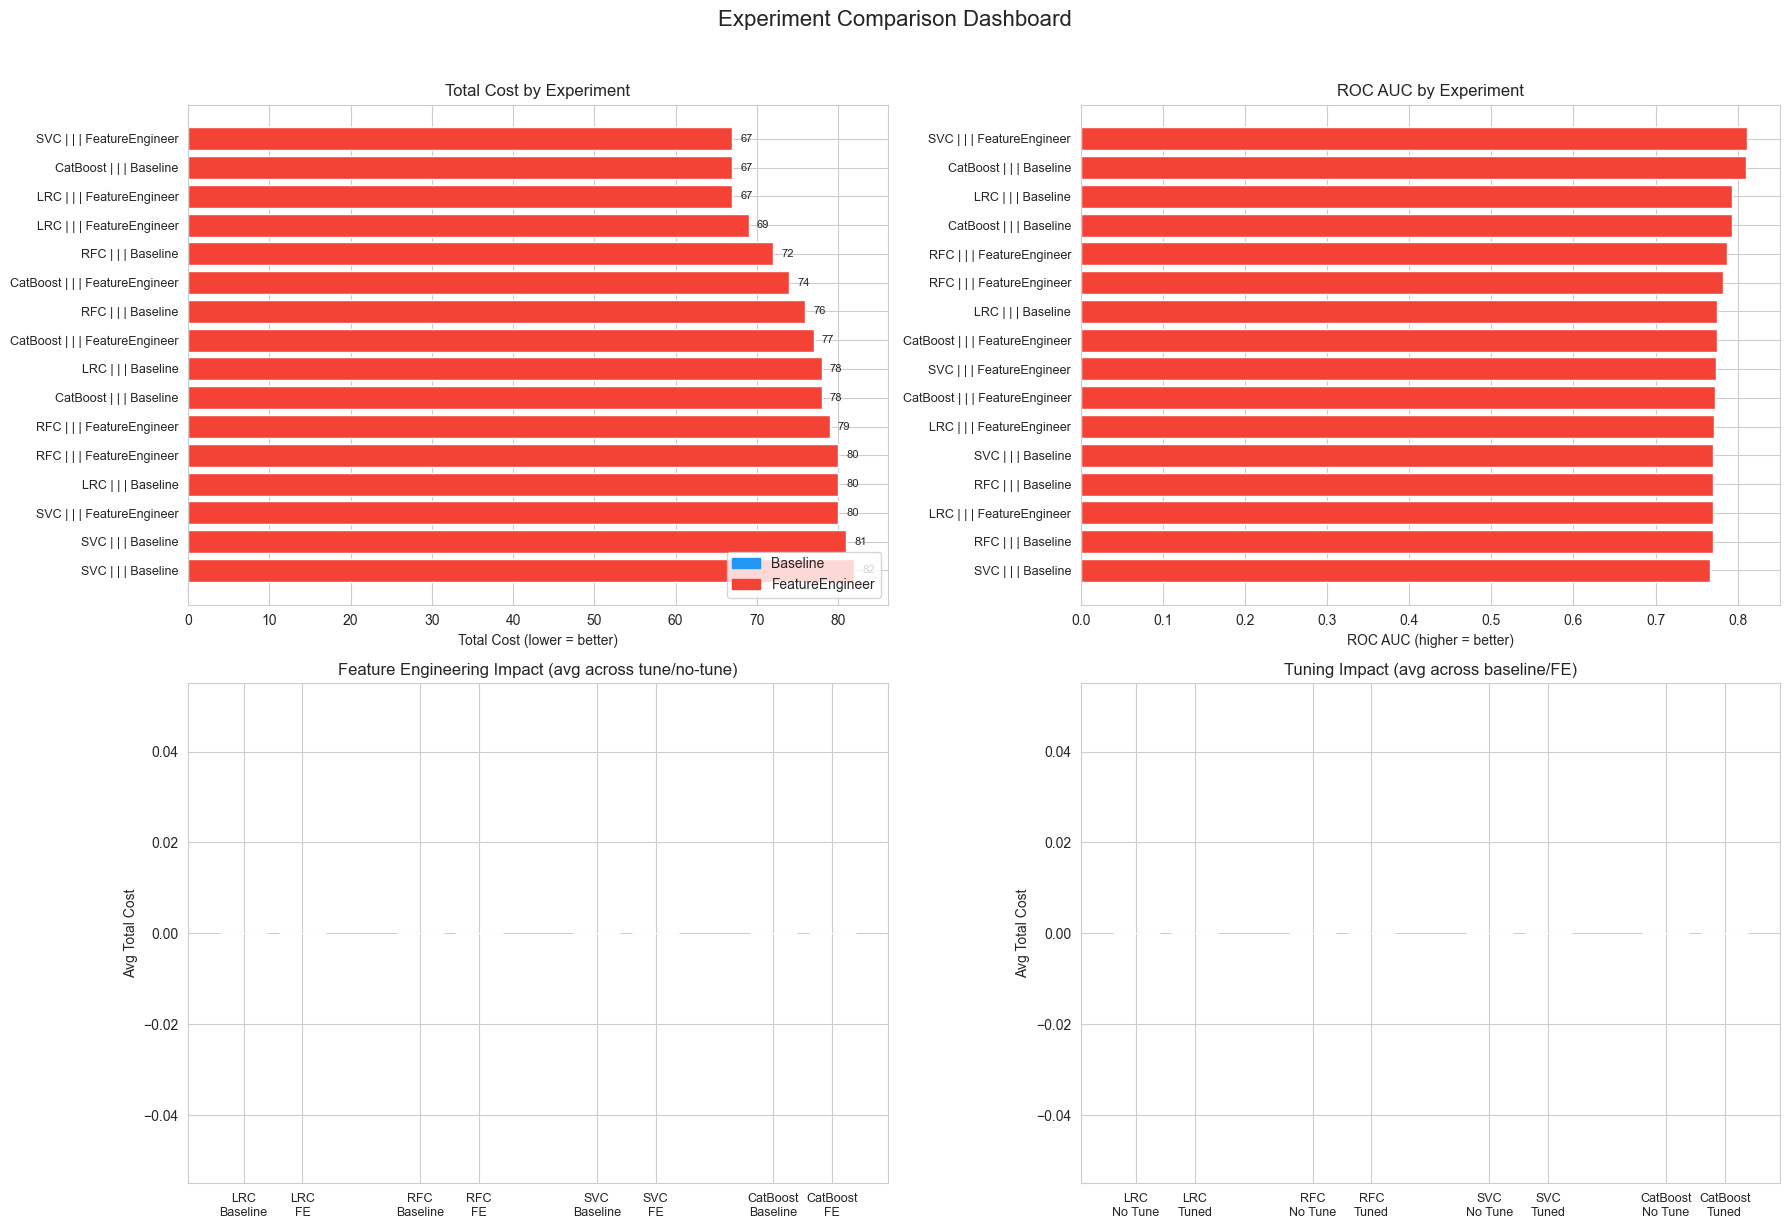

In [32]:
if results_df.empty:
    print("⏭️  No training results to visualise — skip to Section 8.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Total Cost (bar chart, sorted)
    ax = axes[0, 0]
    sorted_df = results_display.sort_values("cost")
    colors = ["#2196F3" if "Baseline" in str(f) else "#F44336" for f in sorted_df["features"]]
    bars = ax.barh(range(len(sorted_df)), sorted_df["cost"], color=colors, edgecolor="white")
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels([f"{r['model']} | {r['features']} | {r['tuning']}" for _, r in sorted_df.iterrows()], fontsize=9)
    ax.set_xlabel("Total Cost (lower = better)")
    ax.set_title("Total Cost by Experiment")
    ax.invert_yaxis()
    for bar, val in zip(bars, sorted_df["cost"]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{val:.0f}", va="center", fontsize=8)

    # 2. ROC AUC (bar chart, sorted)
    ax = axes[0, 1]
    sorted_auc = results_display.sort_values("roc_auc", ascending=False)
    colors_auc = ["#2196F3" if "Baseline" in str(f) else "#F44336" for f in sorted_auc["features"]]
    bars = ax.barh(range(len(sorted_auc)), sorted_auc["roc_auc"], color=colors_auc, edgecolor="white")
    ax.set_yticks(range(len(sorted_auc)))
    ax.set_yticklabels([f"{r['model']} | {r['features']} | {r['tuning']}" for _, r in sorted_auc.iterrows()], fontsize=9)
    ax.set_xlabel("ROC AUC (higher = better)")
    ax.set_title("ROC AUC by Experiment")
    ax.invert_yaxis()

    # 3. Impact of Feature Engineering (grouped by model)
    ax = axes[1, 0]
    model_names = ["LRC", "RFC", "SVC", "CatBoost"]
    x_pos = []
    x_labels = []
    bar_vals = []
    bar_colors = []
    idx = 0
    for model_name in model_names:
        model_df = results_df[results_df["model"] == model_name]
        baseline_rows = model_df[model_df["features"] == "Baseline"]
        fe_rows = model_df[model_df["features"] == "FeatureEngineer"]
        baseline_cost = baseline_rows["cost"].mean() if len(baseline_rows) > 0 else 0
        fe_cost = fe_rows["cost"].mean() if len(fe_rows) > 0 else 0
        x_pos.extend([idx, idx + 1])
        x_labels.extend([f"{model_name}\nBaseline", f"{model_name}\nFE"])
        bar_vals.extend([baseline_cost, fe_cost])
        bar_colors.extend(["#2196F3", "#F44336"])
        idx += 3  # gap between groups

    ax.bar(x_pos, bar_vals, color=bar_colors, edgecolor="white", width=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_ylabel("Avg Total Cost")
    ax.set_title("Feature Engineering Impact (avg across tune/no-tune)")
    # Add value labels
    for xp, val in zip(x_pos, bar_vals):
        if val > 0:
            ax.text(xp, val + 1, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

    # 4. Impact of Tuning (grouped by model)
    ax = axes[1, 1]
    x_pos2 = []
    x_labels2 = []
    bar_vals2 = []
    bar_colors2 = []
    idx = 0
    for model_name in model_names:
        model_df = results_df[results_df["model"] == model_name]
        notune_rows = model_df[model_df["tuning"] == "No Tuning"]
        tuned_rows = model_df[model_df["tuning"] == "Tuned"]
        notune_cost = notune_rows["cost"].mean() if len(notune_rows) > 0 else 0
        tuned_cost = tuned_rows["cost"].mean() if len(tuned_rows) > 0 else 0
        x_pos2.extend([idx, idx + 1])
        x_labels2.extend([f"{model_name}\nNo Tune", f"{model_name}\nTuned"])
        bar_vals2.extend([notune_cost, tuned_cost])
        bar_colors2.extend(["#FFB74D", "#4CAF50"])
        idx += 3

    ax.bar(x_pos2, bar_vals2, color=bar_colors2, edgecolor="white", width=0.8)
    ax.set_xticks(x_pos2)
    ax.set_xticklabels(x_labels2, fontsize=9)
    ax.set_ylabel("Avg Total Cost")
    ax.set_title("Tuning Impact (avg across baseline/FE)")
    for xp, val in zip(x_pos2, bar_vals2):
        if val > 0:
            ax.text(xp, val + 1, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

    # Legend
    from matplotlib.patches import Patch
    axes[0, 0].legend(handles=[Patch(color="#2196F3", label="Baseline"), Patch(color="#F44336", label="FeatureEngineer")], loc="lower right")

    plt.suptitle("Experiment Comparison Dashboard", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 7.2 Key Findings Summary

In [33]:
if results_df.empty:
    print("⏭️  No training results — skip to Section 8.")
else:
    print("=" * 70)
    print("📋 KEY FINDINGS SUMMARY")
    print("=" * 70)

    # Best overall
    best = results_display.iloc[0]
    print(f"\n🏆 Best experiment by ROC AUC: {best['model']} | {best['features']} | {best['tuning']}")
    print(f"   Cost: {best['cost']:.0f}  |  ROC AUC: {best['roc_auc']:.4f}  |  F1: {best['f1']:.4f}")

    # Best per model
    print("\n📊 Best per model (by ROC AUC):")
    for model_name in ["LRC", "RFC", "SVC", "CatBoost"]:
        model_rows = results_display[results_display["model"] == model_name]
        if len(model_rows) > 0:
            model_best = model_rows.iloc[0]
            print(f"   {model_name:>8s}: {model_best['features']:>16s} | {model_best['tuning']:>10s}  →  cost={model_best['cost']:.0f}, AUC={model_best['roc_auc']:.4f}")

    # FE uplift
    print("\n🔧 Feature Engineering uplift (avg cost reduction):")
    for model_name in ["LRC", "RFC", "SVC", "CatBoost"]:
        model_df = results_df[results_df["model"] == model_name]
        baseline_rows = model_df[model_df["features"] == "Baseline"]
        fe_rows = model_df[model_df["features"] == "FeatureEngineer"]
        if len(baseline_rows) > 0 and len(fe_rows) > 0:
            baseline_avg = baseline_rows["cost"].mean()
            fe_avg = fe_rows["cost"].mean()
            delta = baseline_avg - fe_avg
            pct = delta / baseline_avg * 100 if baseline_avg > 0 else 0
            direction = "↓" if delta > 0 else "↑"
            print(f"   {model_name:>8s}: {baseline_avg:.0f} → {fe_avg:.0f}  ({direction} {abs(pct):.1f}%)")

    # Tuning uplift
    print("\n⚙️ Tuning uplift (avg cost reduction):")
    for model_name in ["LRC", "RFC", "SVC", "CatBoost"]:
        model_df = results_df[results_df["model"] == model_name]
        notune_rows = model_df[model_df["tuning"] == "No Tuning"]
        tuned_rows = model_df[model_df["tuning"] == "Tuned"]
        if len(notune_rows) > 0 and len(tuned_rows) > 0:
            notune_avg = notune_rows["cost"].mean()
            tuned_avg = tuned_rows["cost"].mean()
            delta = notune_avg - tuned_avg
            pct = delta / notune_avg * 100 if notune_avg > 0 else 0
            direction = "↓" if delta > 0 else "↑"
            print(f"   {model_name:>8s}: {notune_avg:.0f} → {tuned_avg:.0f}  ({direction} {abs(pct):.1f}%)")

    print("\n" + "=" * 70)
    print("✅ Investigation complete — 16 experiments across 4 models × 4 configs")
    print("=" * 70)

📋 KEY FINDINGS SUMMARY

🏆 Best experiment by ROC AUC: SVC | | | FeatureEngineer
   Cost: 67  |  ROC AUC: 0.8109  |  F1: 0.7624

📊 Best per model (by ROC AUC):
        LRC:                | |   Baseline  →  cost=78, AUC=0.7935
        RFC:                | | FeatureEngineer  →  cost=79, AUC=0.7873
        SVC:                | | FeatureEngineer  →  cost=67, AUC=0.8109
   CatBoost:                | |   Baseline  →  cost=67, AUC=0.8098

🔧 Feature Engineering uplift (avg cost reduction):

⚙️ Tuning uplift (avg cost reduction):

✅ Investigation complete — 16 experiments across 4 models × 4 configs


---
## 8. Ensemble Scoring on Validation Data

We build a **weighted soft-voting ensemble** from the 4 trained pipelines.

**Pipeline source:**
- If you trained all 16 experiments (Sections 3–6), the best-performing configuration per model is used.
- If you loaded from MLflow (Section 7), the registered FeatureEngineer+Tuned pipelines are used.

**Updated workflow:**
1. **8.0** — Load pipelines & compute individual model probabilities
2. **8.1** — Sweep all weight combinations and shortlist the **top 5** by validation **ROC AUC**, then **precision**
3. **8.2** — Score all 5 shortlisted candidates at the **default threshold = 0.5**
4. **8.3** — Tune the threshold for all 5 shortlisted candidates, then **promote** the best ensemble by validation cost
5. **8.4** — Compare the best default-threshold candidate vs the promoted tuned candidate

This makes the weight search less likely to overreact to a single validation winner too early, while still using the project’s **cost** objective for the final promotion step.

In [34]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, average_precision_score, roc_auc_score
)

# ── Select pipeline source ─────────────────────────────────────────────
if LOAD_FROM_MLFLOW and mlflow_pipelines is not None:
    # Use MLflow-loaded pipelines (FeatureEngineer+Tuned from main.py)
    ensemble_pipelines = {
        "lrc": mlflow_pipelines["lrc"],
        "rfc": mlflow_pipelines["rfc"],
        "svc": mlflow_pipelines["svc"],
        "cat": mlflow_pipelines["cat"],
    }
    source_label = "MLflow registry (FeatureEngineer+Tuned)"
else:
    # Use notebook-trained pipelines — best config per model
    ensemble_pipelines = {
        "lrc": lrc_baseline_pipe_tune,    # LRC | Baseline | Tuned
        "rfc": rfc_fe_pipe_tune,          # RFC | FeatureEngineer | Tuned
        "svc": svc_fe_pipe_tune,          # SVC | FeatureEngineer | Tuned
        "cat": cat_baseline_pipe_tune,    # CatBoost | Baseline | Tuned
    }
    source_label = "notebook-trained (best config per model)"

# Initial weights all set to 1.0 (equal weighting) — we'll adjust in the sweep below
ensemble_weights = {
    "lrc": 1.0,
    "rfc": 1.0,
    "svc": 1.0,
    "cat": 1.0,
}

total_weight = sum(ensemble_weights.values())

print("=" * 70)
print("🗳️  ENSEMBLE COMPOSITION")
print("=" * 70)
print(f"   Source: {source_label}")
print(f"   Config weights: {ensemble_weights}")
print(f"   Total weight: {total_weight}")
for key, pipe in ensemble_pipelines.items():
    w = ensemble_weights[key]
    print(f"   {key.upper():>4s}: weight={w:.1f}  ({w/total_weight:.1%})  →  {pipe.steps[-1][1].__class__.__name__}")

# ── Compute individual probabilities on validation set ─────────────────
individual_probas = {}
print(f"\n📊 Individual model ROC AUC on validation set (n={len(y_val)}):")
for key, pipe in ensemble_pipelines.items():
    proba = pipe.predict_proba(X_val)[:, 1]
    individual_probas[key] = proba
    auc = roc_auc_score(y_val, proba)
    print(f"   {key.upper():>4s}: ROC AUC = {auc:.4f}")

print("\n✅ Individual probabilities computed — ready for weight sweep.")

🗳️  ENSEMBLE COMPOSITION
   Source: notebook-trained (best config per model)
   Config weights: {'lrc': 1.0, 'rfc': 1.0, 'svc': 1.0, 'cat': 1.0}
   Total weight: 4.0
    LRC: weight=1.0  (25.0%)  →  LogisticRegression
    RFC: weight=1.0  (25.0%)  →  RandomForestClassifier
    SVC: weight=1.0  (25.0%)  →  SVC
    CAT: weight=1.0  (25.0%)  →  CatBoostSklearnWrapper

📊 Individual model ROC AUC on validation set (n=150):
    LRC: ROC AUC = 0.7935
    RFC: ROC AUC = 0.7822
    SVC: ROC AUC = 0.8109
    CAT: ROC AUC = 0.7925

✅ Individual probabilities computed — ready for weight sweep.


### 8.1 Ensemble Weight Sweep — Shortlist Top 5 by ROC AUC, then Precision

Exhaustive grid search over all 4 model weights in the range **0.5 → 4.0** (step 0.5).

For each of the 4,096 combinations we compute the ensemble probability on the validation set and record:
1. **ROC AUC** — the primary shortlist metric
2. **Precision @ 0.5** — the tie-breaker
3. Supporting diagnostics: average precision, recall, F1, accuracy

At this stage we **do not optimize on cost yet**.
We keep only the **top 5 candidates** and defer the cost-based decision to Sections **8.2** and **8.3**.

In [35]:
from itertools import product as iter_product

# ── Weight grid ────────────────────────────────────────────────────────
weight_values = np.arange(1, 3.5, 0.5)
model_keys = ["lrc", "rfc", "svc", "cat"]
TOP_K_CANDIDATES = 5
DEFAULT_THRESHOLD = 0.5

n_combos = len(weight_values) ** 4
print(f"⏳ Sweeping {n_combos:,} weight combinations ({len(weight_values)} values × 4 models)...")
print(f"   Weight range: {weight_values.tolist()}")
print(f"   Shortlisting rule: ROC AUC ↓ sort, precision @ {DEFAULT_THRESHOLD:.2f} tie-break\n")

sweep_records = []

for w_lrc, w_rfc, w_svc, w_cat in iter_product(weight_values, repeat=4):
    total_w = w_lrc + w_rfc + w_svc + w_cat

    ens_proba = (
        w_lrc * individual_probas["lrc"]
        + w_rfc * individual_probas["rfc"]
        + w_svc * individual_probas["svc"]
        + w_cat * individual_probas["cat"]
    ) / total_w

    ens_pred_default = (ens_proba >= DEFAULT_THRESHOLD).astype(int)

    sweep_records.append({
        "w_lrc": w_lrc,
        "w_rfc": w_rfc,
        "w_svc": w_svc,
        "w_cat": w_cat,
        "roc_auc": roc_auc_score(y_val, ens_proba),
        "average_precision": average_precision_score(y_val, ens_proba),
        "precision_default": precision_score(y_val, ens_pred_default, zero_division=0),
        "recall_default": recall_score(y_val, ens_pred_default, zero_division=0),
        "f1_default": f1_score(y_val, ens_pred_default, zero_division=0),
        "accuracy_default": accuracy_score(y_val, ens_pred_default),
    })

sweep_df = pd.DataFrame(sweep_records).sort_values(
    ["precision_default", "roc_auc", "average_precision", "f1_default"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

candidate_weight_df = sweep_df.head(TOP_K_CANDIDATES).copy()
candidate_weight_df.insert(0, "candidate", [f"C{i}" for i in range(1, len(candidate_weight_df) + 1)])

for key in model_keys:
    weight_col = f"w_{key}"
    pct_col = f"{key}_%"
    candidate_weight_df[pct_col] = (
        candidate_weight_df[weight_col]
        / candidate_weight_df[["w_lrc", "w_rfc", "w_svc", "w_cat"]].sum(axis=1)
        * 100
    ).round(1)

shortlisted_candidates = []
shortlisted_lookup = {}
for shortlist_rank, row in enumerate(candidate_weight_df.to_dict(orient="records"), start=1):
    candidate_label = row["candidate"]
    weights = {key: float(row[f"w_{key}"]) for key in model_keys}
    total_w = sum(weights.values())
    proba = sum(weights[key] * individual_probas[key] for key in model_keys) / total_w

    payload = {
        "candidate": candidate_label,
        "rank": shortlist_rank,
        "weights": weights,
        "proba": proba,
        "roc_auc": float(row["roc_auc"]),
        "average_precision": float(row["average_precision"]),
        "precision_default": float(row["precision_default"]),
        "recall_default": float(row["recall_default"]),
        "f1_default": float(row["f1_default"]),
        "accuracy_default": float(row["accuracy_default"]),
    }
    shortlisted_candidates.append(payload)
    shortlisted_lookup[candidate_label] = payload

config_row = sweep_df[
    (sweep_df["w_lrc"] == config.ensemble.weights["lrc"])
    & (sweep_df["w_rfc"] == config.ensemble.weights["rfc"])
    & (sweep_df["w_svc"] == config.ensemble.weights["svc"])
    & (sweep_df["w_cat"] == config.ensemble.weights["cat"])
]

print("=" * 110)
print(f"🏆 TOP {TOP_K_CANDIDATES} ENSEMBLE CANDIDATES — SORTED BY ROC AUC ↓, PRECISION ↓")
print("=" * 110)
print(f"   Validation set: n={len(y_val)}")
print(f"   Default threshold for shortlist diagnostics: {DEFAULT_THRESHOLD:.2f}")
print(f"   Config weights: LRC={config.ensemble.weights['lrc']}, RFC={config.ensemble.weights['rfc']}, ")
print(f"                   SVC={config.ensemble.weights['svc']}, CAT={config.ensemble.weights['cat']}\n")

styled_candidates = candidate_weight_df[[
    "candidate", "w_lrc", "w_rfc", "w_svc", "w_cat",
    "lrc_%", "rfc_%", "svc_%", "cat_%",
    "roc_auc", "average_precision", "precision_default",
    "recall_default", "f1_default", "accuracy_default",
]].style.format({
    "w_lrc": "{:.1f}", "w_rfc": "{:.1f}", "w_svc": "{:.1f}", "w_cat": "{:.1f}",
    "lrc_%": "{:.1f}%", "rfc_%": "{:.1f}%", "svc_%": "{:.1f}%", "cat_%": "{:.1f}%",
    "roc_auc": "{:.4f}", "average_precision": "{:.4f}",
    "precision_default": "{:.4f}", "recall_default": "{:.4f}",
    "f1_default": "{:.4f}", "accuracy_default": "{:.4f}",
}).background_gradient(subset=["roc_auc"], cmap="RdYlGn").background_gradient(subset=["precision_default"], cmap="Blues")

display(styled_candidates)

best_shortlist = shortlisted_candidates[0]
print(f"\n🥇 Highest-ranked shortlist candidate: {best_shortlist['candidate']}")
print(
    f"   Weights → LRC={best_shortlist['weights']['lrc']:.1f}, RFC={best_shortlist['weights']['rfc']:.1f}, "
    f"SVC={best_shortlist['weights']['svc']:.1f}, CAT={best_shortlist['weights']['cat']:.1f}"
)
print(
    f"   ROC AUC={best_shortlist['roc_auc']:.4f}  |  Precision@0.5={best_shortlist['precision_default']:.4f}  |  "
    f"AP={best_shortlist['average_precision']:.4f}"
)

if not config_row.empty:
    cfg_rank = int(config_row.index[0]) + 1
    cfg = config_row.iloc[0]
    print(f"\n📋 Config weights rank by shortlist rule: #{cfg_rank} of {len(sweep_df):,}")
    print(
        f"   ROC AUC={cfg['roc_auc']:.4f}  |  Precision@0.5={cfg['precision_default']:.4f}  |  "
        f"AP={cfg['average_precision']:.4f}"
    )
    if cfg_rank > TOP_K_CANDIDATES:
        print("   ⚠️ Config weights are outside the promoted top-5 shortlist.")

print("\n✅ Top-5 candidates shortlisted. Next: evaluate all 5 on cost in Sections 8.2 and 8.3.")

⏳ Sweeping 625 weight combinations (5 values × 4 models)...
   Weight range: [1.0, 1.5, 2.0, 2.5, 3.0]
   Shortlisting rule: ROC AUC ↓ sort, precision @ 0.50 tie-break

🏆 TOP 5 ENSEMBLE CANDIDATES — SORTED BY ROC AUC ↓, PRECISION ↓
   Validation set: n=150
   Default threshold for shortlist diagnostics: 0.50
   Config weights: LRC=2.5, RFC=1.5, 
                   SVC=1.5, CAT=1.0

🏆 TOP 5 ENSEMBLE CANDIDATES — SORTED BY ROC AUC ↓, PRECISION ↓
   Validation set: n=150
   Default threshold for shortlist diagnostics: 0.50
   Config weights: LRC=2.5, RFC=1.5, 
                   SVC=1.5, CAT=1.0



,candidate,w_lrc,w_rfc,w_svc,w_cat,lrc_%,rfc_%,svc_%,cat_%,roc_auc,average_precision,precision_default,recall_default,f1_default,accuracy_default
0,C1,3.0,1.0,3.0,1.0,37.5%,12.5%,37.5%,12.5%,0.8047,0.9029,0.8087,0.8774,0.8416,0.7667
1,C2,2.5,1.0,3.0,1.0,33.3%,13.3%,40.0%,13.3%,0.8055,0.9031,0.8051,0.8962,0.8482,0.7733
2,C3,2.0,1.0,3.0,1.0,28.6%,14.3%,42.9%,14.3%,0.8055,0.9031,0.8000,0.9057,0.8496,0.7733
3,C4,2.5,1.5,1.5,1.0,38.5%,23.1%,23.1%,15.4%,0.8038,0.9038,0.7984,0.9340,0.8609,0.7867
4,C5,3.0,2.0,2.0,1.0,37.5%,25.0%,25.0%,12.5%,0.8032,0.9031,0.7984,0.9340,0.8609,0.7867



🥇 Highest-ranked shortlist candidate: C1
   Weights → LRC=3.0, RFC=1.0, SVC=3.0, CAT=1.0
   ROC AUC=0.8047  |  Precision@0.5=0.8087  |  AP=0.9029

📋 Config weights rank by shortlist rule: #4 of 625
   ROC AUC=0.8038  |  Precision@0.5=0.7984  |  AP=0.9038

✅ Top-5 candidates shortlisted. Next: evaluate all 5 on cost in Sections 8.2 and 8.3.


### 8.2 Shortlisted Candidates — Default Threshold Evaluation

We now evaluate **all 5 shortlisted weight combinations** using the default decision boundary of **0.5**.

This is the first place where **cost** re-enters the process.
The goal is to see which shortlisted candidate already behaves best under the project metric **without** threshold tuning, and to compare that against the ROC-AUC-first shortlist ordering from Section **8.1**.

🧪 SHORTLISTED CANDIDATES @ DEFAULT THRESHOLD (0.50)
   Cost matrix: FP=5.0, FN=1.0
   Validation set: n=150



,candidate,shortlist_rank,w_lrc,w_rfc,w_svc,w_cat,cost,avg_cost,roc_auc,average_precision,f1,precision,recall,accuracy
0,C1,1,3.0,1.0,3.0,1.0,123,0.8200,0.8047,0.9029,0.8416,0.8087,0.8774,0.7667
1,C2,2,2.5,1.0,3.0,1.0,126,0.8400,0.8055,0.9031,0.8482,0.8051,0.8962,0.7733
2,C3,3,2.0,1.0,3.0,1.0,130,0.8667,0.8055,0.9031,0.8496,0.8000,0.9057,0.7733
3,C4,4,2.5,1.5,1.5,1.0,132,0.8800,0.8038,0.9038,0.8609,0.7984,0.9340,0.7867
4,C5,5,3.0,2.0,2.0,1.0,132,0.8800,0.8032,0.9031,0.8609,0.7984,0.9340,0.7867



🥇 Best default-threshold shortlist candidate: C1
   Original shortlist rank: #1 by ROC AUC/precision
   Weights → LRC=3.0, RFC=1.0, SVC=3.0, CAT=1.0
                roc_auc: 0.8047
      average_precision: 0.9029
               accuracy: 0.7667
                     f1: 0.8416
              precision: 0.8087
                 recall: 0.8774
                   cost: 123.0000
               avg_cost: 0.8200


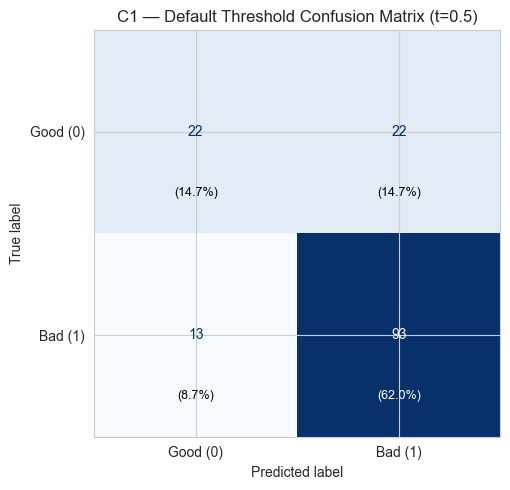

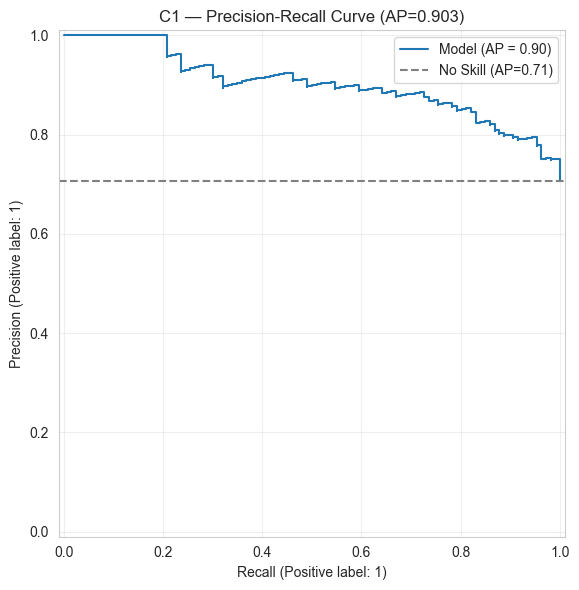

In [36]:
# ── Evaluate all shortlisted candidates at the default threshold ────────
candidate_default_records = []

for candidate in shortlisted_candidates:
    candidate_label = candidate["candidate"]
    ens_proba_candidate = candidate["proba"]
    ens_pred_candidate = (ens_proba_candidate >= DEFAULT_THRESHOLD).astype(int)

    total_cost, avg_cost = calculate_cost(
        y_val.values,
        ens_pred_candidate,
        cost_fp=config.cost_matrix.false_positive,
        cost_fn=config.cost_matrix.false_negative,
    )

    candidate_default_records.append({
        "candidate": candidate_label,
        "shortlist_rank": candidate["rank"],
        "w_lrc": candidate["weights"]["lrc"],
        "w_rfc": candidate["weights"]["rfc"],
        "w_svc": candidate["weights"]["svc"],
        "w_cat": candidate["weights"]["cat"],
        "roc_auc": roc_auc_score(y_val, ens_proba_candidate),
        "average_precision": average_precision_score(y_val, ens_proba_candidate),
        "accuracy": accuracy_score(y_val, ens_pred_candidate),
        "f1": f1_score(y_val, ens_pred_candidate, zero_division=0),
        "precision": precision_score(y_val, ens_pred_candidate, zero_division=0),
        "recall": recall_score(y_val, ens_pred_candidate, zero_division=0),
        "cost": total_cost,
        "avg_cost": avg_cost,
    })

candidate_default_df = pd.DataFrame(candidate_default_records).sort_values(
    ["cost", "roc_auc", "precision"],
    ascending=[True, False, False],
).reset_index(drop=True)

print("=" * 110)
print(f"🧪 SHORTLISTED CANDIDATES @ DEFAULT THRESHOLD ({DEFAULT_THRESHOLD:.2f})")
print("=" * 110)
print(f"   Cost matrix: FP={config.cost_matrix.false_positive}, FN={config.cost_matrix.false_negative}")
print(f"   Validation set: n={len(y_val)}\n")

styled_default = candidate_default_df[[
    "candidate", "shortlist_rank", "w_lrc", "w_rfc", "w_svc", "w_cat",
    "cost", "avg_cost", "roc_auc", "average_precision", "f1", "precision", "recall", "accuracy",
]].style.format({
    "w_lrc": "{:.1f}", "w_rfc": "{:.1f}", "w_svc": "{:.1f}", "w_cat": "{:.1f}",
    "cost": "{:.0f}", "avg_cost": "{:.4f}",
    "roc_auc": "{:.4f}", "average_precision": "{:.4f}",
    "f1": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "accuracy": "{:.4f}",
}).background_gradient(subset=["cost"], cmap="RdYlGn_r").background_gradient(subset=["roc_auc"], cmap="RdYlGn")

display(styled_default)

best_default_candidate = candidate_default_df.iloc[0]
best_default_candidate_label = best_default_candidate["candidate"]
best_default_payload = shortlisted_lookup[best_default_candidate_label]

ensemble_proba_default = best_default_payload["proba"]
ensemble_pred_default = (ensemble_proba_default >= DEFAULT_THRESHOLD).astype(int)
metrics_default = {
    "roc_auc": float(best_default_candidate["roc_auc"]),
    "average_precision": float(best_default_candidate["average_precision"]),
    "accuracy": float(best_default_candidate["accuracy"]),
    "f1": float(best_default_candidate["f1"]),
    "precision": float(best_default_candidate["precision"]),
    "recall": float(best_default_candidate["recall"]),
    "cost": float(best_default_candidate["cost"]),
    "avg_cost": float(best_default_candidate["avg_cost"]),
}

print(f"\n🥇 Best default-threshold shortlist candidate: {best_default_candidate_label}")
print(
    f"   Original shortlist rank: #{int(best_default_candidate['shortlist_rank'])} by ROC AUC/precision"
)
print(
    f"   Weights → LRC={best_default_payload['weights']['lrc']:.1f}, RFC={best_default_payload['weights']['rfc']:.1f}, "
    f"SVC={best_default_payload['weights']['svc']:.1f}, CAT={best_default_payload['weights']['cat']:.1f}"
)
for metric_name, metric_value in metrics_default.items():
    print(f"   {metric_name:>20s}: {metric_value:.4f}")

fig_cm = plot_confusion_matrix(
    y_val.values,
    ensemble_pred_default,
    title=f"{best_default_candidate_label} — Default Threshold Confusion Matrix (t={DEFAULT_THRESHOLD})",
)
plt.show()

fig_pr = plot_precision_recall_curve(
    y_val.values,
    ensemble_proba_default,
    title=f"{best_default_candidate_label} — Precision-Recall Curve",
)
plt.show()

### 8.3 Shortlisted Candidates — Threshold Tuning and Promotion

Now we tune the decision threshold for **each of the 5 shortlisted candidates** by sweeping from **0.01 to 0.99** on the validation set.

At this stage, **cost becomes the promotion criterion**:
- **Primary:** total cost (lower is better)
- **Tie-breakers:** precision, then ROC AUC

The winner of this stage becomes the **promoted ensemble** that advances to the hold-out test set.

🎯 SHORTLISTED CANDIDATES AFTER THRESHOLD TUNING
   Promotion rule: cost ↑ priority, then precision, then ROC AUC
   Validation set: n=150
   Cost matrix: FP=5.0, FN=1.0



,candidate,shortlist_rank,w_lrc,w_rfc,w_svc,w_cat,threshold,cost,avg_cost,roc_auc,average_precision,f1,precision,recall,accuracy
0,C4,4,2.5,1.5,1.5,1.0,0.83,77,0.5133,0.8038,0.9038,0.6164,0.9245,0.4623,0.5933
1,C5,5,3.0,2.0,2.0,1.0,0.83,77,0.5133,0.8032,0.9031,0.6164,0.9245,0.4623,0.5933
2,C3,3,2.0,1.0,3.0,1.0,0.77,76,0.5067,0.8055,0.9031,0.6977,0.9091,0.5660,0.6533
3,C2,2,2.5,1.0,3.0,1.0,0.77,77,0.5133,0.8055,0.9031,0.6901,0.9077,0.5566,0.6467
4,C1,1,3.0,1.0,3.0,1.0,0.72,78,0.5200,0.8047,0.9029,0.7473,0.8947,0.6415,0.6933



🏆 Promoted ensemble candidate: C4
   Original shortlist rank: #4
   Weights → LRC=2.5, RFC=1.5, SVC=1.5, CAT=1.0
   Tuned threshold → 0.83
                roc_auc: 0.8038
      average_precision: 0.9038
               accuracy: 0.5933
                     f1: 0.6164
              precision: 0.9245
                 recall: 0.4623
                   cost: 77.0000
               avg_cost: 0.5133

🔄 Promotion changed the winner from C1 to C4.
   This means the best cost-aware ensemble is not the same as the best default-threshold ensemble.
   Cost delta vs best default candidate: -46 (-37.4%)


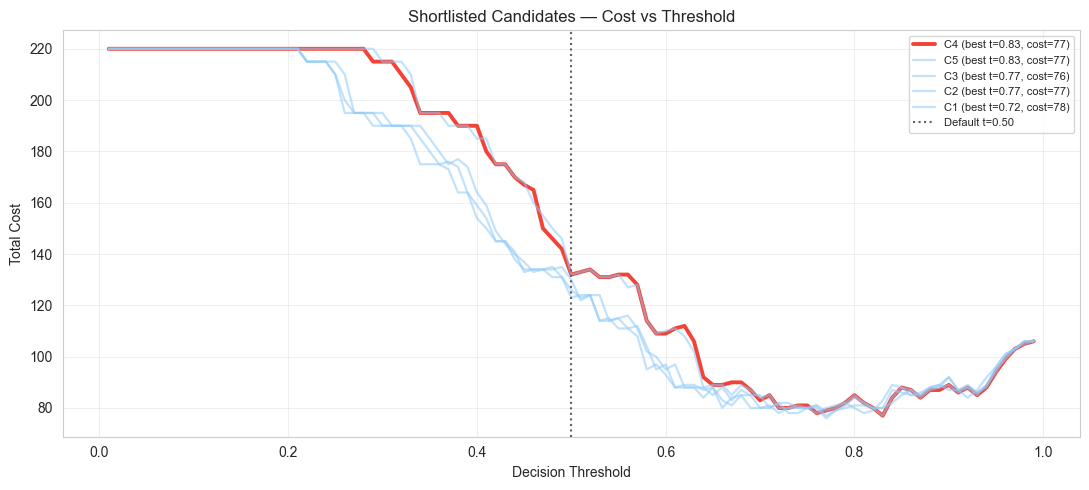

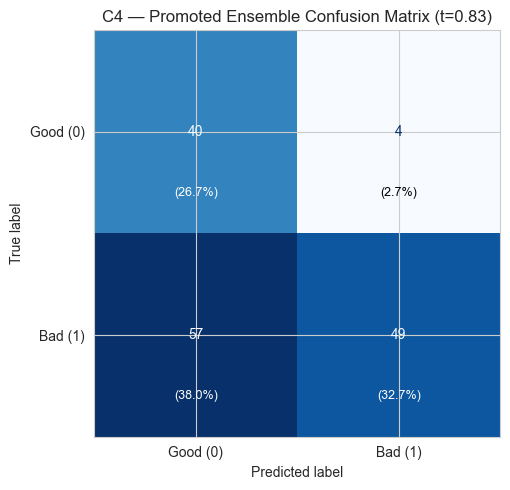

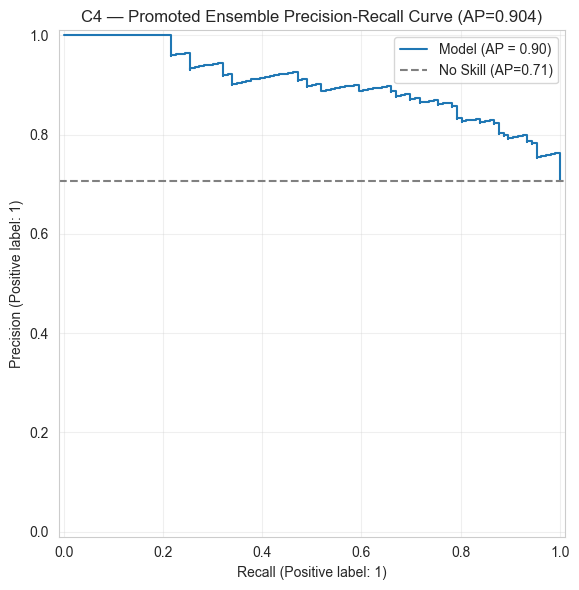

In [37]:
# ── Threshold tuning for all shortlisted candidates ────────────────────
thresholds = np.arange(0.01, 1.0, 0.01)
candidate_tuned_records = []
threshold_curves = {}
cost_fp = config.cost_matrix.false_positive
cost_fn = config.cost_matrix.false_negative

for candidate in shortlisted_candidates:
    candidate_label = candidate["candidate"]
    ens_proba_candidate = candidate["proba"]

    costs_by_threshold = []
    best_threshold_candidate = DEFAULT_THRESHOLD
    best_cost_candidate = float("inf")

    for t in thresholds:
        preds = (ens_proba_candidate >= t).astype(int)
        total_cost, _ = calculate_cost(y_val.values, preds, cost_fp, cost_fn)
        costs_by_threshold.append(total_cost)
        if total_cost < best_cost_candidate:
            best_cost_candidate = total_cost
            best_threshold_candidate = float(t)

    preds_tuned = (ens_proba_candidate >= best_threshold_candidate).astype(int)
    total_cost_tuned, avg_cost_tuned = calculate_cost(y_val.values, preds_tuned, cost_fp, cost_fn)

    candidate_tuned_records.append({
        "candidate": candidate_label,
        "shortlist_rank": candidate["rank"],
        "w_lrc": candidate["weights"]["lrc"],
        "w_rfc": candidate["weights"]["rfc"],
        "w_svc": candidate["weights"]["svc"],
        "w_cat": candidate["weights"]["cat"],
        "threshold": best_threshold_candidate,
        "roc_auc": roc_auc_score(y_val, ens_proba_candidate),
        "average_precision": average_precision_score(y_val, ens_proba_candidate),
        "accuracy": accuracy_score(y_val, preds_tuned),
        "f1": f1_score(y_val, preds_tuned, zero_division=0),
        "precision": precision_score(y_val, preds_tuned, zero_division=0),
        "recall": recall_score(y_val, preds_tuned, zero_division=0),
        "cost": total_cost_tuned,
        "avg_cost": avg_cost_tuned,
    })

    threshold_curves[candidate_label] = {
        "thresholds": thresholds,
        "costs": costs_by_threshold,
        "best_threshold": best_threshold_candidate,
        "best_cost": best_cost_candidate,
    }

candidate_tuned_df = pd.DataFrame(candidate_tuned_records).sort_values(
    ["precision", "roc_auc", "cost"],
    ascending=[False, False, True],
).reset_index(drop=True)

print("=" * 110)
print("🎯 SHORTLISTED CANDIDATES AFTER THRESHOLD TUNING")
print("=" * 110)
print("   Promotion rule: cost ↑ priority, then precision, then ROC AUC")
print(f"   Validation set: n={len(y_val)}")
print(f"   Cost matrix: FP={cost_fp}, FN={cost_fn}\n")

styled_tuned = candidate_tuned_df[[
    "candidate", "shortlist_rank", "w_lrc", "w_rfc", "w_svc", "w_cat",
    "threshold", "cost", "avg_cost", "roc_auc", "average_precision",
    "f1", "precision", "recall", "accuracy",
]].style.format({
    "w_lrc": "{:.1f}", "w_rfc": "{:.1f}", "w_svc": "{:.1f}", "w_cat": "{:.1f}",
    "threshold": "{:.2f}", "cost": "{:.0f}", "avg_cost": "{:.4f}",
    "roc_auc": "{:.4f}", "average_precision": "{:.4f}",
    "f1": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "accuracy": "{:.4f}",
}).background_gradient(subset=["cost"], cmap="RdYlGn_r").background_gradient(subset=["roc_auc"], cmap="RdYlGn")

display(styled_tuned)

promoted_candidate = candidate_tuned_df.iloc[0]
promoted_candidate_label = promoted_candidate["candidate"]
promoted_payload = shortlisted_lookup[promoted_candidate_label]

ensemble_weights = promoted_payload["weights"].copy()
total_weight = sum(ensemble_weights.values())
ensemble_proba = promoted_payload["proba"]
best_threshold = float(promoted_candidate["threshold"])
ensemble_pred_tuned = (ensemble_proba >= best_threshold).astype(int)
metrics_tuned = {
    "roc_auc": float(promoted_candidate["roc_auc"]),
    "average_precision": float(promoted_candidate["average_precision"]),
    "accuracy": float(promoted_candidate["accuracy"]),
    "f1": float(promoted_candidate["f1"]),
    "precision": float(promoted_candidate["precision"]),
    "recall": float(promoted_candidate["recall"]),
    "cost": float(promoted_candidate["cost"]),
    "avg_cost": float(promoted_candidate["avg_cost"]),
}
selected_ensemble_candidate = promoted_candidate_label

print(f"\n🏆 Promoted ensemble candidate: {promoted_candidate_label}")
print(f"   Original shortlist rank: #{int(promoted_candidate['shortlist_rank'])}")
print(
    f"   Weights → LRC={ensemble_weights['lrc']:.1f}, RFC={ensemble_weights['rfc']:.1f}, "
    f"SVC={ensemble_weights['svc']:.1f}, CAT={ensemble_weights['cat']:.1f}"
)
print(f"   Tuned threshold → {best_threshold:.2f}")
for metric_name, metric_value in metrics_tuned.items():
    print(f"   {metric_name:>20s}: {metric_value:.4f}")

if promoted_candidate_label == best_default_candidate_label:
    print("\nℹ️ Promotion kept the same weight combination as the default-threshold winner.")
    print("   The gain here comes purely from threshold tuning.")
else:
    print(f"\n🔄 Promotion changed the winner from {best_default_candidate_label} to {promoted_candidate_label}.")
    print("   This means the best cost-aware ensemble is not the same as the best default-threshold ensemble.")

cost_delta_vs_default = metrics_tuned["cost"] - metrics_default["cost"]
print(
    f"   Cost delta vs best default candidate: {cost_delta_vs_default:+.0f} "
    f"({(cost_delta_vs_default / metrics_default['cost'] * 100) if metrics_default['cost'] else 0:+.1f}%)"
)

fig, ax = plt.subplots(figsize=(11, 5))
for row in candidate_tuned_df.itertuples(index=False):
    curve = threshold_curves[row.candidate]
    color = "#F44336" if row.candidate == promoted_candidate_label else "#90CAF9"
    alpha = 1.0 if row.candidate == promoted_candidate_label else 0.55
    linewidth = 2.8 if row.candidate == promoted_candidate_label else 1.6
    ax.plot(
        curve["thresholds"],
        curve["costs"],
        color=color,
        alpha=alpha,
        linewidth=linewidth,
        label=f"{row.candidate} (best t={row.threshold:.2f}, cost={row.cost:.0f})",
    )

ax.axvline(DEFAULT_THRESHOLD, color="#616161", linestyle=":", linewidth=1.5, label=f"Default t={DEFAULT_THRESHOLD:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Cost")
ax.set_title("Shortlisted Candidates — Cost vs Threshold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

fig_cm = plot_confusion_matrix(
    y_val.values,
    ensemble_pred_tuned,
    title=f"{promoted_candidate_label} — Promoted Ensemble Confusion Matrix (t={best_threshold:.2f})",
)
plt.show()

fig_pr = plot_precision_recall_curve(
    y_val.values,
    ensemble_proba,
    title=f"{promoted_candidate_label} — Promoted Ensemble Precision-Recall Curve",
)
plt.show()

### 8.4 Comparison — Best Default Candidate vs Promoted Tuned Candidate

This side-by-side comparison shows what changed between:
- the **best shortlisted candidate at the default threshold** from Section **8.2**
- the **promoted candidate after threshold tuning** from Section **8.3**

If both labels are the same, then the improvement comes from **threshold tuning only**.
If the labels differ, then both the **weight mix** and the **threshold** changed before promotion.

🔬 DEFAULT WINNER VS PROMOTED ENSEMBLE
   Default-stage winner:  C1
   Promoted candidate:    C4
   Validation set: n=150
   Cost matrix: FP=5.0, FN=1.0



,Metric,C1 Default (t=0.50),C4 Promoted (t=0.83),Delta,Δ (%)
0,roc_auc,0.8047,0.8038,-0.0009,-0.1%
1,average_precision,0.9029,0.9038,+0.0009,+0.1%
2,accuracy,0.7667,0.5933,-0.1733,-22.6%
3,f1,0.8416,0.6164,-0.2253,-26.8%
4,precision,0.8087,0.9245,+0.1158,+14.3%
5,recall,0.8774,0.4623,-0.4151,-47.3%
6,cost,123.0000,77.0000,-46.0000,-37.4%
7,avg_cost,0.8200,0.5133,-0.3067,-37.4%


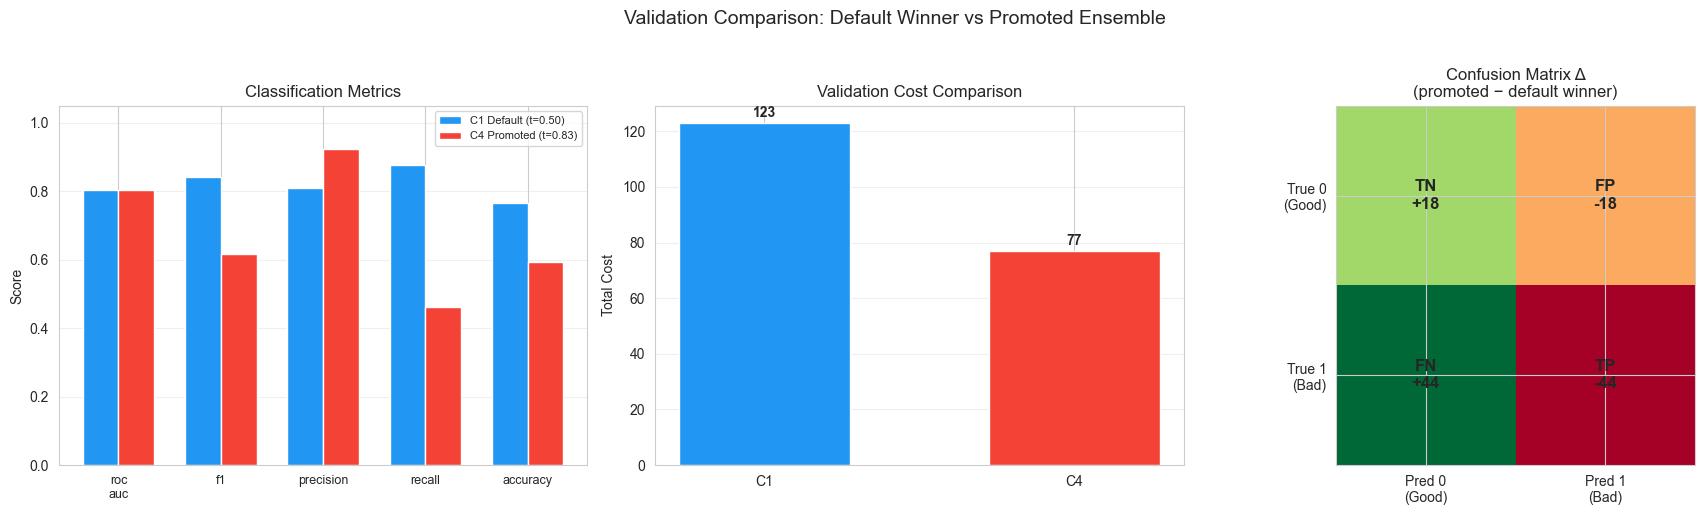


💡 Promotion ↓ reduced validation cost by 46 (37.4%)
   Default-stage winner: C1 @ t=0.50
   Promoted candidate:   C4 @ t=0.83
   Interpretation: the best cost-aware candidate is different from the default-threshold winner.
   ROC AUC:   0.8047 → 0.8038
   F1:        0.8416 → 0.6164
   Recall:    0.8774 → 0.4623
   Precision: 0.8087 → 0.9245


In [38]:
# ── Side-by-side comparison table ──────────────────────────────────────
default_label = best_default_candidate_label
promoted_label = promoted_candidate_label

default_col = f"{default_label} Default (t={DEFAULT_THRESHOLD:.2f})"
promoted_col = f"{promoted_label} Promoted (t={best_threshold:.2f})"

comparison_data = {
    "Metric": list(metrics_default.keys()),
    default_col: list(metrics_default.values()),
    promoted_col: list(metrics_tuned.values()),
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df["Delta"] = comparison_df[promoted_col] - comparison_df[default_col]
comparison_df["Δ (%)"] = comparison_df["Delta"] / comparison_df[default_col].abs().replace(0, np.nan) * 100

print("=" * 90)
print("🔬 DEFAULT WINNER VS PROMOTED ENSEMBLE")
print("=" * 90)
print(f"   Default-stage winner:  {default_label}")
print(f"   Promoted candidate:    {promoted_label}")
print(f"   Validation set: n={len(y_val)}")
print(f"   Cost matrix: FP={cost_fp}, FN={cost_fn}")
print()

styled_cmp = comparison_df.style.format({
    default_col: "{:.4f}",
    promoted_col: "{:.4f}",
    "Delta": "{:+.4f}",
    "Δ (%)": "{:+.1f}%",
}).background_gradient(subset=["Delta"], cmap="RdYlGn_r")

display(styled_cmp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
bar_metrics = ["roc_auc", "f1", "precision", "recall", "accuracy"]
x = np.arange(len(bar_metrics))
width = 0.35
vals_default = [metrics_default[m] for m in bar_metrics]
vals_tuned = [metrics_tuned[m] for m in bar_metrics]
ax.bar(x - width / 2, vals_default, width, label=default_col, color="#2196F3", edgecolor="white")
ax.bar(x + width / 2, vals_tuned, width, label=promoted_col, color="#F44336", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in bar_metrics], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Classification Metrics")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
costs = [metrics_default["cost"], metrics_tuned["cost"]]
bars = ax.bar(
    [default_label, promoted_label],
    costs,
    color=["#2196F3", "#F44336"],
    edgecolor="white",
    width=0.55,
)
for bar, val in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{val:.0f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Total Cost")
ax.set_title("Validation Cost Comparison")
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
from sklearn.metrics import confusion_matrix as cm_func
cm_default = cm_func(y_val, ensemble_pred_default)
cm_tuned = cm_func(y_val, ensemble_pred_tuned)
cm_diff = cm_tuned - cm_default

labels = np.array([
    [f"TN\n{cm_diff[0, 0]:+d}", f"FP\n{cm_diff[0, 1]:+d}"],
    [f"FN\n{cm_diff[1, 0]:+d}", f"TP\n{cm_diff[1, 1]:+d}"],
])
scale = np.max(np.abs(cm_diff))
im = ax.imshow(cm_diff, cmap="RdYlGn", vmin=-scale if scale else -1, vmax=scale if scale else 1)
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=12, fontweight="bold")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0\n(Good)", "Pred 1\n(Bad)"])
ax.set_yticklabels(["True 0\n(Good)", "True 1\n(Bad)"])
ax.set_title("Confusion Matrix Δ\n(promoted − default winner)")

plt.suptitle("Validation Comparison: Default Winner vs Promoted Ensemble", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

cost_delta = metrics_tuned["cost"] - metrics_default["cost"]
cost_pct = cost_delta / metrics_default["cost"] * 100 if metrics_default["cost"] != 0 else 0
direction = "↓ reduced" if cost_delta < 0 else ("↑ increased" if cost_delta > 0 else "= unchanged")

print(f"\n💡 Promotion {direction} validation cost by {abs(cost_delta):.0f} ({abs(cost_pct):.1f}%)")
print(f"   Default-stage winner: {default_label} @ t={DEFAULT_THRESHOLD:.2f}")
print(f"   Promoted candidate:   {promoted_label} @ t={best_threshold:.2f}")
if default_label == promoted_label:
    print("   Interpretation: same weights won, threshold tuning made the difference.")
else:
    print("   Interpretation: the best cost-aware candidate is different from the default-threshold winner.")
print(f"   ROC AUC:   {metrics_default['roc_auc']:.4f} → {metrics_tuned['roc_auc']:.4f}")
print(f"   F1:        {metrics_default['f1']:.4f} → {metrics_tuned['f1']:.4f}")
print(f"   Recall:    {metrics_default['recall']:.4f} → {metrics_tuned['recall']:.4f}")
print(f"   Precision: {metrics_default['precision']:.4f} → {metrics_tuned['precision']:.4f}")

---
## 9. Final Evaluation on the Hold-Out Test Set

Everything up to this point used the **validation set** (150 samples drawn from the training data).
Now we evaluate on the **completely unseen test set** (`test_data.csv`) to get an unbiased estimate
of real-world performance.

We score:
1. Each of the **4 individual models** (using their own cost-optimal thresholds)
2. The **promoted ensemble candidate** from Section **8.3** using its promoted **weights** and **threshold**

Then we compare all five to see whether the promoted ensemble truly beats the best individual model on unseen data.

In [39]:
# ══════════════════════════════════════════════════════════════════════
# 9.0 — Load test set & score all models + promoted ensemble
# ══════════════════════════════════════════════════════════════════════

# ── Load the hold-out test set ─────────────────────────────────────────
test_df = pd.read_csv(DATA_DIR / config.test_data_file)
X_test = test_df.drop(columns=[config.target])
y_test = test_df[config.target]

print(f"📊 Test set loaded: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"   Target distribution: {dict(y_test.value_counts())}")
print(f"   Positive rate: {y_test.mean():.1%}\n")

# ── Retrieve per-model thresholds learned on the VALIDATION set ────────
# These were tuned in Sections 3–6 (notebook) or stored as MLflow metrics
# by main.py. We NEVER sweep on the test set — that would be data leakage.
model_labels = {"lrc": "Logistic Regression", "rfc": "Random Forest", "svc": "SVC", "cat": "CatBoost"}

if LOAD_FROM_MLFLOW and mlflow_pipelines is not None:
    import mlflow
    client = mlflow.tracking.MlflowClient()

    model_thresholds = {}
    for key in ensemble_pipelines:
        registry_name = config.models[key].registry_name
        versions = client.search_model_versions(f"name='{registry_name}'")
        latest_ver = max(versions, key=lambda v: int(v.version)) if versions else None
        if latest_ver:
            run_data = client.get_run(latest_ver.run_id).data
            model_thresholds[key] = run_data.metrics.get("tuned_decision_threshold", 0.5)
        else:
            model_thresholds[key] = 0.5
    print("🔧 Thresholds loaded from MLflow run metrics (validation-set tuned):")
else:
    _experiment_for_key = {
        "lrc": "LRC | Baseline | Tuned",
        "rfc": "RFC | FeatureEngineer | Tuned",
        "svc": "SVC | FeatureEngineer | Tuned",
        "cat": "CatBoost | Baseline | Tuned",
    }
    _results_lookup = {r["experiment"]: r for r in ALL_RESULTS}

    model_thresholds = {}
    for key, exp_name in _experiment_for_key.items():
        if exp_name in _results_lookup:
            model_thresholds[key] = _results_lookup[exp_name]["threshold"]
        else:
            model_thresholds[key] = 0.5
            print(f"   ⚠️ {exp_name!r} not found in ALL_RESULTS — using 0.5")
    print("🔧 Thresholds loaded from ALL_RESULTS (validation-set tuned):")

for key in ensemble_pipelines:
    print(f"   {key.upper():>4s}: threshold = {model_thresholds[key]:.2f}")

best_ens_t = best_threshold
print(
    f"   ENS : candidate = {selected_ensemble_candidate}, threshold = {best_ens_t:.2f} "
    f"(promoted in Section 8.3)\n"
)

# ── Score each individual model on the test set ────────────────────────
test_results = []

for key, pipe in ensemble_pipelines.items():
    proba_test = pipe.predict_proba(X_test)[:, 1]
    best_t = model_thresholds[key]
    preds = (proba_test >= best_t).astype(int)
    tc, ac = calculate_cost(y_test.values, preds, cost_fp, cost_fn)

    row = {
        "model": model_labels[key],
        "key": key,
        "type": "Individual",
        "candidate": "—",
        "threshold": best_t,
        "roc_auc": roc_auc_score(y_test, proba_test),
        "average_precision": average_precision_score(y_test, proba_test),
        "f1": f1_score(y_test, preds, zero_division=0),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "accuracy": accuracy_score(y_test, preds),
        "cost": tc,
        "avg_cost": ac,
    }
    test_results.append(row)

# ── Score the promoted ensemble on the test set ────────────────────────
ens_proba_test = np.zeros(len(X_test))
for key, pipe in ensemble_pipelines.items():
    ens_proba_test += ensemble_weights[key] * pipe.predict_proba(X_test)[:, 1]
ens_proba_test /= sum(ensemble_weights.values())

ens_preds_test = (ens_proba_test >= best_ens_t).astype(int)
ens_tc, ens_ac = calculate_cost(y_test.values, ens_preds_test, cost_fp, cost_fn)

ens_row = {
    "model": "🗳️ Ensemble",
    "key": "ensemble",
    "type": "Ensemble",
    "candidate": selected_ensemble_candidate,
    "threshold": best_ens_t,
    "roc_auc": roc_auc_score(y_test, ens_proba_test),
    "average_precision": average_precision_score(y_test, ens_proba_test),
    "f1": f1_score(y_test, ens_preds_test, zero_division=0),
    "precision": precision_score(y_test, ens_preds_test, zero_division=0),
    "recall": recall_score(y_test, ens_preds_test, zero_division=0),
    "accuracy": accuracy_score(y_test, ens_preds_test),
    "cost": ens_tc,
    "avg_cost": ens_ac,
}
test_results.append(ens_row)

# ── Build results table ───────────────────────────────────────────────
test_results_df = pd.DataFrame(test_results)

display_cols = [
    "model", "type", "candidate", "threshold", "cost", "avg_cost",
    "roc_auc", "average_precision", "f1", "precision", "recall", "accuracy",
]
test_display = test_results_df[display_cols].copy()

print("=" * 100)
print("🧪 TEST SET EVALUATION — INDIVIDUAL MODELS VS PROMOTED ENSEMBLE")
print("=" * 100)
print(f"   Test set: n={len(y_test)}")
print(f"   Cost matrix: FP={cost_fp}, FN={cost_fn}")
print(f"   Promoted candidate: {selected_ensemble_candidate}")
print(
    f"   Promoted weights: LRC={ensemble_weights['lrc']:.1f}, RFC={ensemble_weights['rfc']:.1f}, "
    f"SVC={ensemble_weights['svc']:.1f}, CAT={ensemble_weights['cat']:.1f}"
)
print(f"   Promoted threshold: {best_ens_t:.2f}\n")

styled_test = test_display.style.format({
    "threshold": "{:.2f}", "cost": "{:.0f}", "avg_cost": "{:.4f}",
    "roc_auc": "{:.4f}", "average_precision": "{:.4f}", "f1": "{:.4f}",
    "precision": "{:.4f}", "recall": "{:.4f}", "accuracy": "{:.4f}",
}).background_gradient(subset=["cost"], cmap="RdYlGn_r").background_gradient(subset=["roc_auc"], cmap="RdYlGn").apply(
    lambda row: ["font-weight: bold" if row["type"] == "Ensemble" else "" for _ in row],
    axis=1,
)

display(styled_test)

📊 Test set loaded: 159 samples, 20 features
   Target distribution: {1: np.int64(106), 0: np.int64(53)}
   Positive rate: 66.7%

🔧 Thresholds loaded from ALL_RESULTS (validation-set tuned):
    LRC: threshold = 0.72
    RFC: threshold = 0.90
    SVC: threshold = 0.69
    CAT: threshold = 0.91
   ENS : candidate = C4, threshold = 0.83 (promoted in Section 8.3)

🧪 TEST SET EVALUATION — INDIVIDUAL MODELS VS PROMOTED ENSEMBLE
   Test set: n=159
   Cost matrix: FP=5.0, FN=1.0
   Promoted candidate: C4
   Promoted weights: LRC=2.5, RFC=1.5, SVC=1.5, CAT=1.0
   Promoted threshold: 0.83

🧪 TEST SET EVALUATION — INDIVIDUAL MODELS VS PROMOTED ENSEMBLE
   Test set: n=159
   Cost matrix: FP=5.0, FN=1.0
   Promoted candidate: C4
   Promoted weights: LRC=2.5, RFC=1.5, SVC=1.5, CAT=1.0
   Promoted threshold: 0.83



,model,type,candidate,threshold,cost,avg_cost,roc_auc,average_precision,f1,precision,recall,accuracy
0,Logistic Regression,Individual,—,0.72,80,0.5031,0.7942,0.8811,0.7011,0.8971,0.5755,0.6730
1,Random Forest,Individual,—,0.90,81,0.5094,0.8033,0.8873,0.7568,0.8861,0.6604,0.7170
2,SVC,Individual,—,0.69,92,0.5786,0.8165,0.8902,0.7708,0.8605,0.6981,0.7233
3,CatBoost,Individual,—,0.91,91,0.5723,0.8021,0.8897,0.7487,0.8642,0.6604,0.7044
4,🗳️ Ensemble,Ensemble,C4,0.83,78,0.4906,0.8072,0.8866,0.6824,0.9062,0.5472,0.6604


### 9.1 Ensemble Advantage — Visual Comparison

How much does the ensemble improve over the best individual model on the unseen test set?

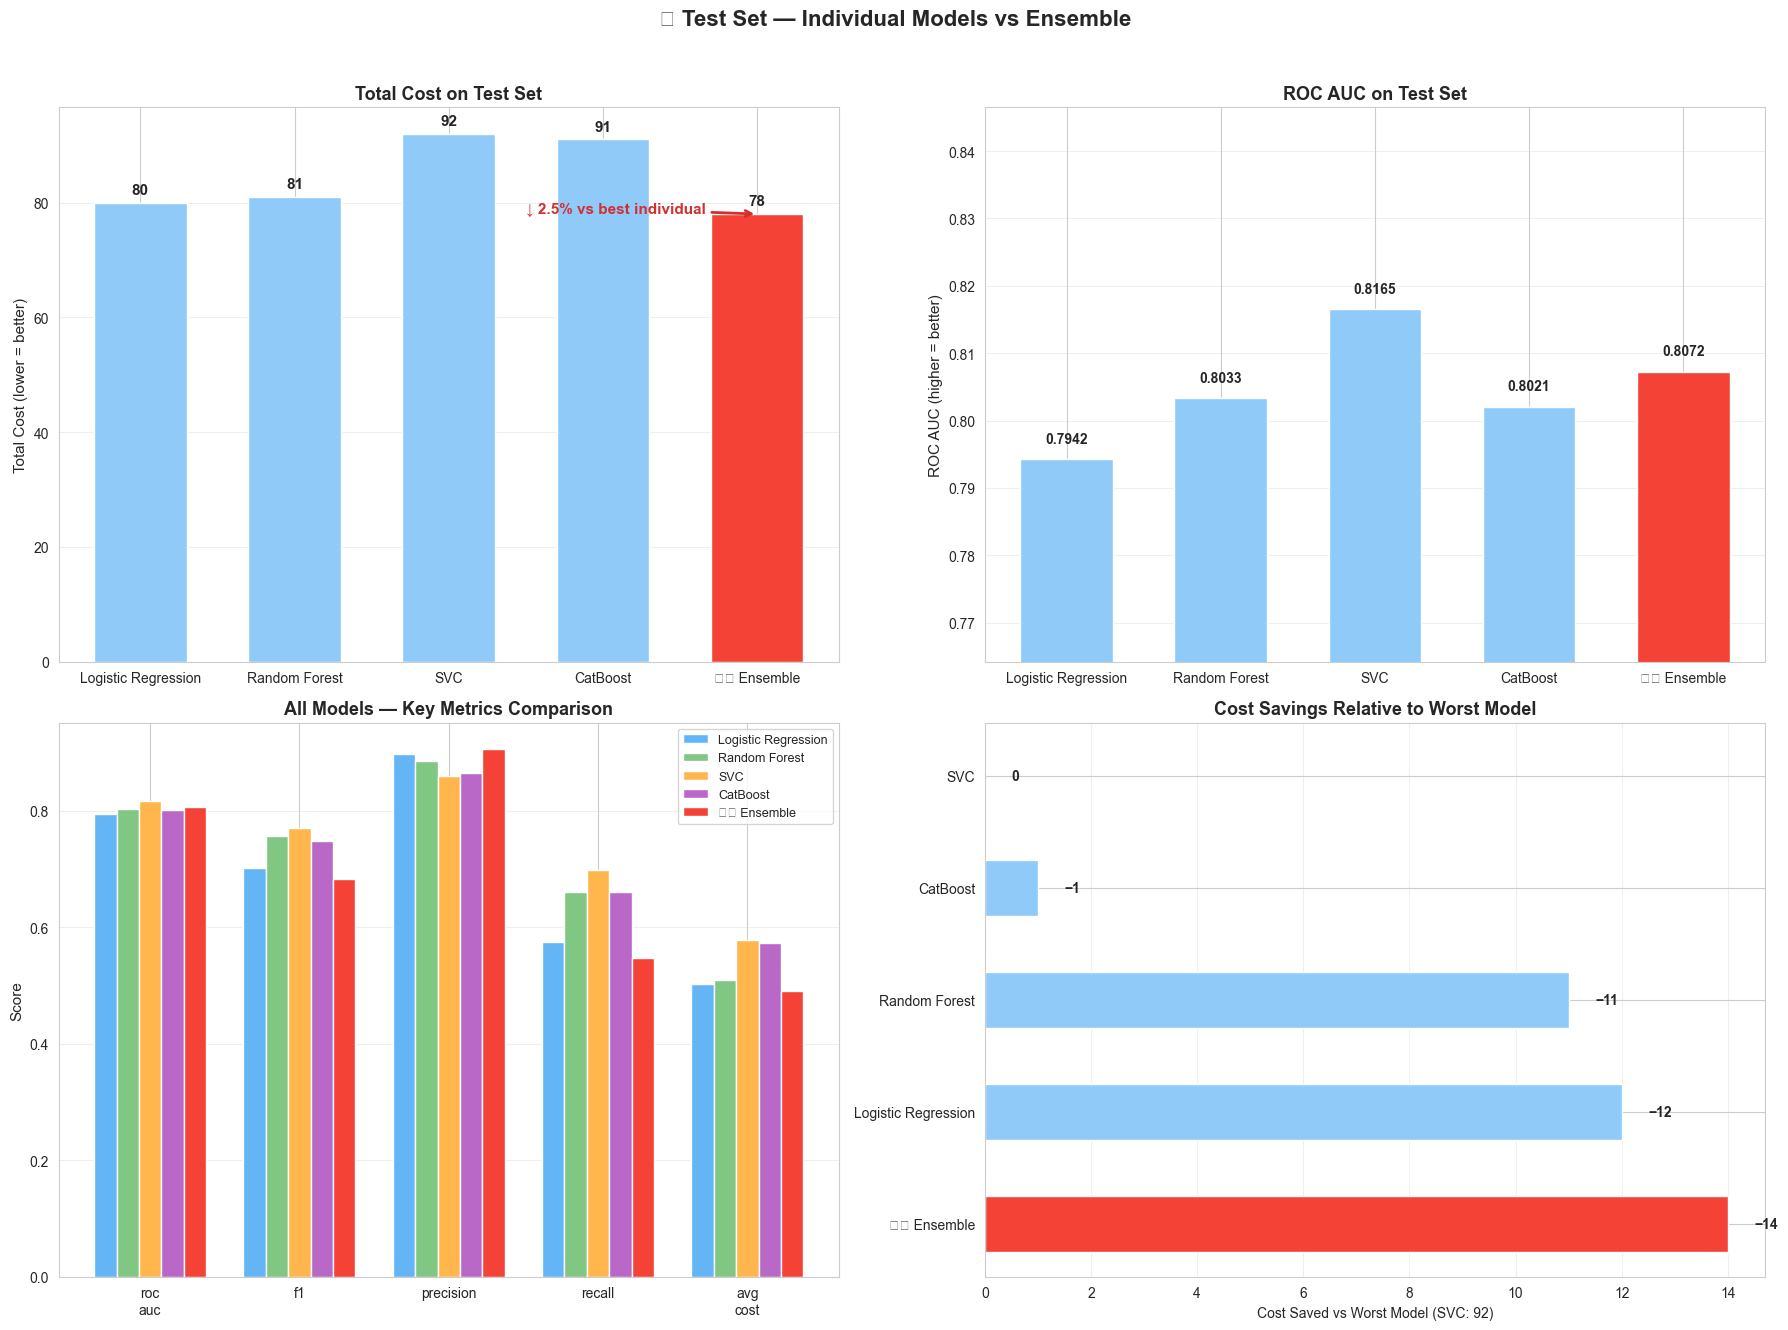

In [40]:
# ══════════════════════════════════════════════════════════════════════
# 9.1 — Ensemble vs Individual Models — Visual Comparison
# ══════════════════════════════════════════════════════════════════════

indiv = test_results_df[test_results_df["type"] == "Individual"].copy()
ens = test_results_df[test_results_df["type"] == "Ensemble"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# ── 1. Total Cost Bar Chart ──────────────────────────────────────────
ax = axes[0, 0]
all_names = list(indiv["model"]) + [ens["model"]]
all_costs = list(indiv["cost"]) + [ens["cost"]]
colors = ["#90CAF9"] * len(indiv) + ["#F44336"]

bars = ax.bar(all_names, all_costs, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, all_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Total Cost (lower = better)", fontsize=11)
ax.set_title("Total Cost on Test Set", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

# Add improvement annotation from best individual to ensemble
best_indiv_cost = indiv["cost"].min()
best_indiv_name = indiv.loc[indiv["cost"].idxmin(), "model"]
if best_indiv_cost > 0:
    improvement = (best_indiv_cost - ens["cost"]) / best_indiv_cost * 100
    ax.annotate(
        f"{'↓' if improvement > 0 else '↑'} {abs(improvement):.1f}% vs best individual",
        xy=(len(indiv), ens["cost"]),
        xytext=(len(indiv) - 1.5, max(all_costs) * 0.85),
        fontsize=11, fontweight="bold", color="#D32F2F",
        arrowprops=dict(arrowstyle="->", color="#D32F2F", lw=2),
    )

# ── 2. ROC AUC Bar Chart ─────────────────────────────────────────────
ax = axes[0, 1]
all_aucs = list(indiv["roc_auc"]) + [ens["roc_auc"]]
bars = ax.bar(all_names, all_aucs, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, all_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_ylabel("ROC AUC (higher = better)", fontsize=11)
ax.set_title("ROC AUC on Test Set", fontsize=13, fontweight="bold")
ax.set_ylim(min(all_aucs) - 0.03, max(all_aucs) + 0.03)
ax.grid(axis="y", alpha=0.3)

# ── 3. Multi-metric Radar / Grouped Bar ───────────────────────────────
ax = axes[1, 0]
compare_metrics = ["roc_auc", "f1", "precision", "recall", "avg_cost"]
x = np.arange(len(compare_metrics))
width = 0.15
model_colors = {"lrc": "#64B5F6", "rfc": "#81C784", "svc": "#FFB74D", "cat": "#BA68C8"}
ensemble_color = "#F44336"

# Plot each individual model
for i, (_, row) in enumerate(indiv.iterrows()):
    vals = [row[m] for m in compare_metrics]
    ax.bar(x + i * width, vals, width, label=row["model"],
           color=model_colors.get(row["key"], "#BDBDBD"), edgecolor="white")

# Plot ensemble
ens_vals = [ens[m] for m in compare_metrics]
ax.bar(x + len(indiv) * width, ens_vals, width, label=ens["model"],
       color=ensemble_color, edgecolor="white")

ax.set_xticks(x + width * len(indiv) / 2)
ax.set_xticklabels([m.replace("_", "\n") for m in compare_metrics], fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("All Models — Key Metrics Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)

# ── 4. Cost Savings Waterfall ─────────────────────────────────────────
ax = axes[1, 1]

# Sort individual models by cost (worst to best)
indiv_sorted = indiv.sort_values("cost", ascending=False)
worst_cost = indiv_sorted.iloc[0]["cost"]

savings = []
labels_wf = []
for _, row in indiv_sorted.iterrows():
    savings.append(worst_cost - row["cost"])
    labels_wf.append(row["model"])
savings.append(worst_cost - ens["cost"])
labels_wf.append(ens["model"])

colors_wf = ["#90CAF9"] * len(indiv_sorted) + ["#F44336"]
bars = ax.barh(labels_wf, savings, color=colors_wf, edgecolor="white", height=0.5)
for bar, val in zip(bars, savings):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"−{val:.0f}" if val > 0 else f"{val:.0f}",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel(f"Cost Saved vs Worst Model ({indiv_sorted.iloc[0]['model']}: {worst_cost:.0f})", fontsize=10)
ax.set_title("Cost Savings Relative to Worst Model", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

plt.suptitle("🧪 Test Set — Individual Models vs Ensemble", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 9.2 Final Verdict

In [41]:
# ══════════════════════════════════════════════════════════════════════
# 9.2 — Final Verdict
# ══════════════════════════════════════════════════════════════════════

best_indiv = indiv.loc[indiv["cost"].idxmin()]
best_indiv_auc = indiv.loc[indiv["roc_auc"].idxmax()]

print("=" * 80)
print("🏁 FINAL VERDICT — TEST SET PERFORMANCE")
print("=" * 80)

print(f"\n📊 Test set: n={len(y_test)}, positive rate={y_test.mean():.1%}")
print(f"💰 Cost matrix: FP={cost_fp}, FN={cost_fn}")

print(f"\n{'─' * 60}")
print("📌 INDIVIDUAL MODELS (test set, cost-optimal threshold)")
print(f"{'─' * 60}")
for _, row in indiv.iterrows():
    print(
        f"   {row['model']:>22s}:  cost={row['cost']:>5.0f}  |  AUC={row['roc_auc']:.4f}  |  "
        f"F1={row['f1']:.4f}  |  t={row['threshold']:.2f}"
    )

print(f"\n{'─' * 60}")
print("🗳️  PROMOTED ENSEMBLE")
print(f"{'─' * 60}")
print(f"   Candidate:  {selected_ensemble_candidate}")
print(
    f"   Weights:    LRC={ensemble_weights['lrc']:.1f}, RFC={ensemble_weights['rfc']:.1f}, "
    f"SVC={ensemble_weights['svc']:.1f}, CAT={ensemble_weights['cat']:.1f}"
)
print(f"   Threshold:  {ens['threshold']:.2f}")
print(f"   Cost:       {ens['cost']:.0f}")
print(f"   ROC AUC:    {ens['roc_auc']:.4f}")
print(f"   F1:         {ens['f1']:.4f}")

cost_saved = best_indiv["cost"] - ens["cost"]
cost_saved_pct = cost_saved / best_indiv["cost"] * 100 if best_indiv["cost"] > 0 else 0

auc_gain = ens["roc_auc"] - best_indiv_auc["roc_auc"]
auc_gain_pct = auc_gain / best_indiv_auc["roc_auc"] * 100 if best_indiv_auc["roc_auc"] > 0 else 0

print(f"\n{'─' * 60}")
print("🔎 WHY THIS ENSEMBLE WAS PROMOTED")
print(f"{'─' * 60}")
print(f"   Shortlist stage winner by ROC AUC/precision: {shortlisted_candidates[0]['candidate']}")
print(f"   Best default-threshold candidate:            {best_default_candidate_label}")
print(f"   Final promoted candidate after tuning:       {promoted_candidate_label}")
if promoted_candidate_label == best_default_candidate_label:
    print("   Interpretation: validation cost confirmed the same weight mix after tuning the threshold.")
else:
    print("   Interpretation: the best cost-aware ensemble was not the same as the default-threshold winner.")

print(f"\n{'─' * 60}")
print("🏆 ENSEMBLE ADVANTAGE")
print(f"{'─' * 60}")

if cost_saved > 0:
    print(
        f"   ✅ Cost reduced by {cost_saved:.0f} ({cost_saved_pct:.1f}%) "
        f"vs best individual ({best_indiv['model']})"
    )
elif cost_saved == 0:
    print(f"   ➡️  Cost equals best individual ({best_indiv['model']})")
else:
    print(
        f"   ⚠️  Cost increased by {abs(cost_saved):.0f} ({abs(cost_saved_pct):.1f}%) "
        f"vs best individual ({best_indiv['model']})"
    )

if auc_gain > 0:
    print(
        f"   ✅ ROC AUC improved by {auc_gain:.4f} ({auc_gain_pct:.1f}%) "
        f"vs best individual ({best_indiv_auc['model']})"
    )
elif auc_gain == 0:
    print(f"   ➡️  ROC AUC equals best individual ({best_indiv_auc['model']})")
else:
    print(
        f"   ⚠️  ROC AUC dropped by {abs(auc_gain):.4f} ({abs(auc_gain_pct):.1f}%) "
        f"vs best individual ({best_indiv_auc['model']})"
    )

print(f"\n   Ensemble vs each individual (cost delta):")
for _, row in indiv.iterrows():
    delta = row["cost"] - ens["cost"]
    pct = delta / row["cost"] * 100 if row["cost"] > 0 else 0
    arrow = "↓" if delta > 0 else ("↑" if delta < 0 else "=")
    print(f"     vs {row['model']:>22s}: {arrow} {abs(delta):.0f} ({abs(pct):.1f}%)")

print(f"\n{'=' * 80}")
print("✅ Investigation complete.")
print("=" * 80)

🏁 FINAL VERDICT — TEST SET PERFORMANCE

📊 Test set: n=159, positive rate=66.7%
💰 Cost matrix: FP=5.0, FN=1.0

────────────────────────────────────────────────────────────
📌 INDIVIDUAL MODELS (test set, cost-optimal threshold)
────────────────────────────────────────────────────────────
      Logistic Regression:  cost=   80  |  AUC=0.7942  |  F1=0.7011  |  t=0.72
            Random Forest:  cost=   81  |  AUC=0.8033  |  F1=0.7568  |  t=0.90
                      SVC:  cost=   92  |  AUC=0.8165  |  F1=0.7708  |  t=0.69
                 CatBoost:  cost=   91  |  AUC=0.8021  |  F1=0.7487  |  t=0.91

────────────────────────────────────────────────────────────
🗳️  PROMOTED ENSEMBLE
────────────────────────────────────────────────────────────
   Candidate:  C4
   Weights:    LRC=2.5, RFC=1.5, SVC=1.5, CAT=1.0
   Threshold:  0.83
   Cost:       78
   ROC AUC:    0.8072
   F1:         0.6824

────────────────────────────────────────────────────────────
🔎 WHY THIS ENSEMBLE WAS PROMOTED
───────

### 9.3 Production MLflow Ensemble vs Notebook Ensemble

Run the next cell **after** Section **9.0** has been executed, because it depends on the existing test-set variables already created in this notebook:
- `X_test`, `y_test`
- `cost_fp`, `cost_fn`
- `best_ens_t`, `ensemble_weights`, `selected_ensemble_candidate`
- notebook test outputs such as `ens_row` (or the fallback `ens_proba_test` / `ens_preds_test`)

The next cell loads the **production MLflow ensemble** (`credit-risk-ensemble`), scores it on the same hold-out test set, compares it to the notebook ensemble, and prints the notebook parameters in a copy-friendly format for manual updates to `model_config.yml`.

In [ ]:
import mlflow
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, precision_score, recall_score, roc_auc_score

print("=" * 100)
print("🏭 PRODUCTION ENSEMBLE VS NOTEBOOK ENSEMBLE — TEST SET COMPARISON")
print("=" * 100)

mlflow.set_tracking_uri(config.mlflow["backend_store_uri"])
production_model_uri = "models:/credit-risk-ensemble/latest"
production_ensemble_model = mlflow.pyfunc.load_model(production_model_uri)
production_predictions = production_ensemble_model.predict(X_test)

production_proba_test = production_predictions["probability"].to_numpy()
production_pred_test = production_predictions["decision"].to_numpy().astype(int)
production_threshold = float(production_predictions["threshold"].iloc[0])

production_cost, production_avg_cost = calculate_cost(
    y_test.values,
    production_pred_test,
    cost_fp,
    cost_fn,
)

production_metrics = {
    "roc_auc": roc_auc_score(y_test, production_proba_test),
    "average_precision": average_precision_score(y_test, production_proba_test),
    "accuracy": accuracy_score(y_test, production_pred_test),
    "f1": f1_score(y_test, production_pred_test, zero_division=0),
    "precision": precision_score(y_test, production_pred_test, zero_division=0),
    "recall": recall_score(y_test, production_pred_test, zero_division=0),
    "cost": production_cost,
    "avg_cost": production_avg_cost,
}

if "ens_row" in globals():
    notebook_metrics = {
        "roc_auc": float(ens_row["roc_auc"]),
        "average_precision": float(ens_row["average_precision"]),
        "accuracy": float(ens_row["accuracy"]),
        "f1": float(ens_row["f1"]),
        "precision": float(ens_row["precision"]),
        "recall": float(ens_row["recall"]),
        "cost": float(ens_row["cost"]),
        "avg_cost": float(ens_row["avg_cost"]),
    }
else:
    notebook_metrics = {
        "roc_auc": roc_auc_score(y_test, ens_proba_test),
        "average_precision": average_precision_score(y_test, ens_proba_test),
        "accuracy": accuracy_score(y_test, ens_preds_test),
        "f1": f1_score(y_test, ens_preds_test, zero_division=0),
        "precision": precision_score(y_test, ens_preds_test, zero_division=0),
        "recall": recall_score(y_test, ens_preds_test, zero_division=0),
        "cost": ens_tc,
        "avg_cost": ens_ac,
    }

comparison_df = pd.DataFrame({
    "Metric": list(production_metrics.keys()),
    f"Production MLflow (t={production_threshold:.2f})": list(production_metrics.values()),
    f"Notebook Ensemble (t={best_ens_t:.2f})": list(notebook_metrics.values()),
})
comparison_df["Delta (Notebook - Production)"] = comparison_df.iloc[:, 2] - comparison_df.iloc[:, 1]
comparison_df["Δ (%)"] = comparison_df["Delta (Notebook - Production)"] / comparison_df.iloc[:, 1].abs().replace(0, np.nan) * 100

print(f"   Loaded production model URI: {production_model_uri}")
print(f"   Production threshold: {production_threshold:.2f}")
print(f"   Notebook candidate: {selected_ensemble_candidate}")
print(f"   Notebook threshold: {best_ens_t:.2f}")
print()

display(
    comparison_df.style.format({
        f"Production MLflow (t={production_threshold:.2f})": "{:.4f}",
        f"Notebook Ensemble (t={best_ens_t:.2f})": "{:.4f}",
        "Delta (Notebook - Production)": "{:+.4f}",
        "Δ (%)": "{:+.1f}%",
    }).background_gradient(subset=["Delta (Notebook - Production)"], cmap="RdYlGn_r")
)

print("\n📋 Manual config values to copy into model_config.yml:")
print(f"   threshold: {best_ens_t:.2f}")
print("   weights:")
print(f"     lrc: {ensemble_weights['lrc']:.1f}")
print(f"     rfc: {ensemble_weights['rfc']:.1f}")
print(f"     svc: {ensemble_weights['svc']:.1f}")
print(f"     cat: {ensemble_weights['cat']:.1f}")

🏭 PRODUCTION ENSEMBLE VS NOTEBOOK ENSEMBLE — TEST SET COMPARISON
   Loaded production model URI: models:/credit-risk-ensemble/latest
   Production threshold: 0.83
   Notebook candidate: C4
   Notebook threshold: 0.83

   Loaded production model URI: models:/credit-risk-ensemble/latest
   Production threshold: 0.83
   Notebook candidate: C4
   Notebook threshold: 0.83



,Metric,Production MLflow (t=0.83),Notebook Ensemble (t=0.83),Delta (Notebook - Production),Δ (%)
0,roc_auc,0.8186,0.8072,-0.0114,-1.4%
1,average_precision,0.8942,0.8866,-0.0076,-0.8%
2,accuracy,0.6289,0.6604,+0.0314,+5.0%
3,f1,0.6380,0.6824,+0.0443,+6.9%
4,precision,0.9123,0.9062,-0.0060,-0.7%
5,recall,0.4906,0.5472,+0.0566,+11.5%
6,cost,79.0000,78.0000,-1.0000,-1.3%
7,avg_cost,0.4969,0.4906,-0.0063,-1.3%



📋 Manual config values to copy into model_config.yml:
   threshold: 0.83
   weights:
     lrc: 2.5
     rfc: 1.5
     svc: 1.5
     cat: 1.0

💡 Interpretation:
   Notebook ensemble has lower test-set cost than the current production MLflow ensemble.
